# Quantitative Investment Analytics Framework

## Project Overview
This project develops a quantitative portfolio analytics framework that integrates Modern Portfolio Theory (MPT), risk analytics, and performance attribution into a single workflow. 

It supports both individual asset and portfolio-level analysis, enabling portfolio optimization, benchmark comparison, and comprehensive risk assessment through statistical and financial models.

## Key Features
### Data Processing and Input Validation
- Automatic financial data retrieval from Yahoo Finance
- Daily return generation from adjusted closing prices
- Duplicate ticker and benchmark detection with automatic duplicate removal
- Invalid or unavailable ticker handling after data download
- Flexible user input for tickers, benchmarks, date range, rolling window, and number of Monte Carlo simulations

### Portfolio Optimization
- Monte Carlo portfolio simulation
- Maximum Sharpe Ratio Portfolio
- Minimum Volatility Portfolio
- Equal Weight Portfolio
- Efficient Frontier visualization
- Portfolio weight allocation summary

### Performance Analytics
- Annualized return
- Annualized volatility
- Sharpe ratio
- Portfolio and benchmark ranking
- Combined portfolio and benchmark performance summary

### Risk Analytics
- Value at Risk (VaR)
- Conditional Value at Risk (CVaR)
- CAPM analysis: Alpha, Beta, R², and residual volatility
- Portfolio and benchmark risk comparison

### Drawdown Analysis
- Portfolio growth comparison
- Benchmark growth comparison
- Portfolio drawdown trend
- Benchmark drawdown trend
- Maximum drawdown calculation
- Drawdown ranking across portfolios and benchmarks

### Rolling Analytics
- Rolling return
- Rolling volatility
- Rolling Sharpe ratio
- Rolling beta
- Ticker-level and portfolio-level rolling analysis

### Market and Correlation Analytics
- Covariance matrix
- Correlation matrix
- Correlation heatmap
- Highest and lowest correlation pair analysis
- Diversification insight generation

### Reporting and Export
- Automated summary table generation
- Plot generation and export
- CSV output export for key analytics results
- Organized output folders for data and plots

Author:
Wielly Halim

Language:
Python

## Project Roadmap

| Phase | Description | Status |
|-------|-------------|:------:|
| Phase 1 | Portfolio Analytics & Optimization | ✅ Complete |
| Phase 2 | Advanced Portfolio Construction | 🔄 Planned |
| Phase 3 | Factor Investing & Quantitative Research | ⏳ Planned |
| Phase 4 | Interactive Analytics Platform | ⏳ Planned |

## Table of Contents
1. Import Libraries
2. Function Definitions
3. User Configuration
4. Data Download
5. Performance Summary
6. Portfolio Optimization
7. Risk Analysis
8. Rolling Analytics

### 1. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

### 2. Function Definitions

In [2]:
# ===========================
# Data Extraction 
# ===========================
def get_user_inputs():
    """
    Collect and validate user inputs for portfolio analytics.
    This function prompts the user to enter portfolio tickers,
    benchmark tickers, analysis period, rolling window size,
    Monte Carlo simulation settings, and plotting preferences.
    Duplicate tickers are automatically removed while preserving
    their original order. Basic input validation is performed
    before returning the configuration.
    
    Returns
    -------
    dict
        Dictionary containing the validated user configuration with
        the following keys:
        tickers : list[str]
            Portfolio ticker symbols.
        benchmark_tickers : list[str]
            Benchmark ticker symbols.
        start_date : pandas.Timestamp
            Analysis start date.
        end_date : pandas.Timestamp
            Analysis end date.
        risk_free_rate_annual : float
            Annual risk-free rate used for performance metrics.
        trading_days : int
            Number of trading days per year used for annualization.
        rolling_period : int
            Rolling window size for rolling analytics.
        benchmark_filter : str or None
            Selected benchmark ticker for rolling beta plots.
            None indicates all benchmarks will be plotted.
        num_portfolios : int
            Number of random portfolios generated for the
            Monte Carlo simulation.
        plot_benchmark : bool
            Whether benchmark series should be included in
            rolling metric plots.
    Raises
    ------
    ValueError
        If fewer than two portfolio tickers are provided,
        no benchmark ticker is provided, or the start date
        is later than the end date.
    """
    tickers_input = input ("Enter tickers separated by comma, e.g. AAPL, GOOGL, META: ")

# =====================================
# Portfolio Tickers
# =====================================
    tickers = [
        ticker.strip().upper()
        for ticker in tickers_input.split(",")
        if ticker.strip()
    ]

# Check duplicate portfolio tickers
    duplicate_tickers = [
        ticker
        for ticker in set(tickers)
        if tickers.count(ticker) > 1
    ]

    if duplicate_tickers:
        print(
            f"Duplicate portfolio ticker(s) detected: "
            f"{duplicate_tickers}. Duplicates removed."
        )

# Remove duplicates while preserving order

    tickers = list(dict.fromkeys(tickers))

    # =====================================
    # Benchmark Tickers
    # =====================================

    benchmark_ticker_input = input(
    "Enter benchmark tickers separated by comma, e.g. SPY, VOO, QQQ: "
)
    benchmark_tickers = [
        ticker.strip().upper()
        for ticker in benchmark_ticker_input.split(",")
        if ticker.strip()
    ]

# Check duplicate benchmark tickers
    duplicate_benchmark_tickers = [
        ticker
        for ticker in set(benchmark_tickers)
        if benchmark_tickers.count(ticker) > 1
    ]

    if duplicate_benchmark_tickers:
        print(
            f"Duplicate benchmark ticker(s) detected: "
            f"{duplicate_benchmark_tickers}. Duplicates removed."
        )

# Remove duplicates while preserving order
    benchmark_tickers = list(dict.fromkeys(benchmark_tickers))
    
    start_date_input = input("Enter start date YYYY-MM-DD, e.g. 2020-01-01: ")
    end_date_input = input("Enter end date YYYY-MM-DD, or leave empty for today's date: ")
    start_date = pd.to_datetime(start_date_input)
    if end_date_input.strip() == "":
        end_date = pd.to_datetime(date.today())
    else:
        end_date = pd.to_datetime(end_date_input)

    risk_free_rate_annual = 0.03
    trading_days = 252

    while True:
        try:
            rolling_period = round(float(input("Enter rolling window (days): ")))
            if rolling_period <= 0:
                print("Please enter positive number.")
                continue
            break
        except ValueError:
            print("Invalid input.")
    if len(tickers) < 2:
        raise ValueError("Please enter at least 2 tickers.")
    if len(benchmark_tickers) < 1:
        raise ValueError("Please enter at least 1 benchmark ticker.")
    if start_date > end_date:
        raise ValueError("Start date must be earlier than the end date.")
    
    while True:
        benchmark_filter = (
            input('Enter benchmark ticker or type "None" to plot all benchmarks: ').strip().upper()
        )
        if benchmark_filter == "NONE":
            benchmark_filter = None
            break
        elif benchmark_filter in benchmark_tickers:
            benchmark_filter = benchmark_filter
            break
        else:
            print(
                f"Invalid benchmark. Available benchmarks: "
                f"{(benchmark_tickers)}"
            )

    num_portfolios = int(input("Enter the number of simulation for portfolio Monte Carlo simulation: "))

    plot_benchmark_input = input("Plot benchmark in rolling metric charts? Yes/No: ").strip().lower()
    plot_benchmark = plot_benchmark_input in ["yes", "y"]

    return {
        "tickers": tickers,
        "benchmark_tickers": benchmark_tickers,
        "start_date": start_date,
        "end_date": end_date,
        "risk_free_rate_annual": risk_free_rate_annual,
        "trading_days": trading_days,
        "rolling_period": rolling_period,
        "benchmark_filter": benchmark_filter,
        "num_portfolios": num_portfolios,
        "plot_benchmark": plot_benchmark
    }

def download_yfinance_data(
        tickers,
        start_date,
        end_date,
        auto_adjust=True
):
    """
    Download historical market data from Yahoo Finance for use throughout the portfolio analytics workflow.”
    Retrieves historical price data for one or more ticker symbols
    over the specified date range using the yfinance library.
    
    Parameters
    ----------
    tickers : list[str] or str
        Portfolio or benchmark ticker symbol(s) to download.
    start_date : pandas.Timestamp or str
        Start date of the historical data.
    end_date : pandas.Timestamp or str
        End date of the historical data.
    auto_adjust : bool, default=True
        Whether to automatically adjust historical prices for
        dividends and stock splits.
    
    Returns
    -------
    pandas.DataFrame
        Historical market data indexed by date.
    """
    return yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        auto_adjust=auto_adjust,
        progress=False
    )

def prepare_return_data(
    data,
    input_tickers
):
    """
    Validate downloaded market data and generate daily return series.
    This function extracts adjusted closing prices from the downloaded
    Yahoo Finance data, identifies valid and invalid ticker symbols,
    removes unavailable assets, and computes daily percentage returns
    for the remaining valid tickers.

    Parameters
    ----------
    data : pandas.DataFrame
        Historical market data downloaded from Yahoo Finance.
    input_tickers : list[str]
        List of user-specified ticker symbols.

    Returns
    -------
    close_df : pandas.DataFrame
        Closing price data for valid ticker symbols.
    daily_return : pandas.DataFrame
        Daily percentage returns calculated from the closing prices.
    valid_tickers : list[str]
        Ticker symbols with available historical price data.
    invalid_tickers : list[str]
        Ticker symbols that were invalid or contained no usable data.

    Raises
    ------
    ValueError
        If no valid ticker symbols remain after validation.
    Notes
    -----
    - Invalid or unavailable ticker symbols are automatically excluded
      from the analysis.
    - Rows containing missing daily returns are removed to ensure
      consistent calculations across all assets.
    """

    close_df = data["Close"].copy()
    if isinstance(close_df, pd.Series):
        close_df = close_df.to_frame(name=input_tickers[0])

    valid_tickers = []
    invalid_tickers = []

    for ticker in input_tickers:
        if ticker not in close_df.columns:
            invalid_tickers.append(ticker)
        elif close_df[ticker].dropna().empty:
            invalid_tickers.append(ticker)
        else:
            valid_tickers.append(ticker)

    if invalid_tickers:
        print(f"\nInvalid or unavailable ticker(s): {invalid_tickers}")
        print(f"Continuing with valid ticker(s): {valid_tickers}")

    if len(valid_tickers) == 0:
        raise ValueError("No valid tickers available.")
    close_df = close_df[valid_tickers]
    daily_return = close_df.pct_change().dropna(how="all")
    daily_return = daily_return.dropna()
    return close_df, daily_return, valid_tickers, invalid_tickers

def create_output_folders(
    base_dir="output"):
    
    """
    Create the output directory structure for storing project results.
    This function creates separate folders for exported data tables
    and generated figures. If the folders already exist, they are
    preserved without modification.
    
    Parameters
    ----------
    base_dir : str, default="output"
        Root directory used to store all exported project outputs.
    
    Returns
    -------
    data_path : pathlib.Path
        Path to the directory for exported data files (e.g., CSV).
    plot_path : pathlib.Path
        Path to the directory for exported visualization files
        (e.g., PNG).
    
    Notes
    -----
    The following directory structure is created automatically:
        output/
        ├── data/
        └── plots/
    Existing directories are not overwritten.
    """

    base_path = Path(base_dir)
    data_path = base_path / "data"
    plot_path = base_path / "plots"
    data_path.mkdir(parents=True, exist_ok=True)
    plot_path.mkdir(parents=True, exist_ok=True)

    return data_path, plot_path

def save_dataframe(
        df,
        filename,
        output_dir
        ):

    """
    Save a DataFrame to a CSV or Excel file.
    Exports the provided DataFrame to the specified output directory.
    The output file format is automatically determined from the
    filename extension.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame to be exported.
    filename : str
        Output filename including the file extension. Supported
        extensions are '.csv' and '.xlsx'.
    output_dir : pathlib.Path
        Directory where the output file will be saved.
    
    Raises
    ------
    ValueError
        If the filename extension is not '.csv' or '.xlsx'.
    
    Notes
    -----
    - DataFrame indices are preserved in the exported file.
    - Existing files with the same filename will be overwritten.
    """

    filepath = output_dir / filename
    if filename.endswith(".csv"):
        df.to_csv(filepath, index=True)
    elif filename.endswith(".xlsx"):
        df.to_excel(filepath, index=True)
    else:
        raise ValueError("Filename must end with .csv or .xlsx")
    print(f"Saved: {filepath}✅")

def save_current_plot(
        filename,
        output_dir,
        dpi=300):
    """
    Save the current Matplotlib figure to an image file.
    Exports the active Matplotlib figure to the specified output
    directory using the provided filename and image resolution.
    
    Parameters
    ----------
    filename : str
        Output filename, including the desired image extension
        (e.g., '.png', '.jpg', '.pdf').
    output_dir : pathlib.Path
        Directory where the figure will be saved.
    dpi : int, default=300
        Resolution of the exported figure in dots per inch (DPI).
    Notes
    -----
    - The figure is saved using ``bbox_inches="tight"`` to minimize
      unnecessary whitespace around the plot.
    - Existing files with the same filename will be overwritten.
    """

    filepath = output_dir / filename
    plt.savefig(filepath, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {filepath}✅")

# ===========================
# Calculation Functions
# ===========================
def calculate_performance_summary(
    daily_return,
    risk_free_rate_annual,
    trading_days
):
    """
    Calculate annualized performance metrics for one or more assets.
    Computes the annualized return, annualized volatility, and Sharpe
    ratio from daily return series. The function supports both
    individual return series and multiple return series stored in a
    DataFrame.
    
    Parameters
    ----------
    daily_return : pandas.Series or pandas.DataFrame
        Daily return series for a single asset/portfolio or multiple
        assets/portfolios.
    risk_free_rate_annual : float
        Annual risk-free rate used to calculate the Sharpe ratio.
    trading_days : int
        Number of trading days per year used for annualization.
    
    Returns
    -------
    pandas.DataFrame
        Summary table containing the following performance metrics:
        - Annual Return (%)
        - Volatility (%)
        - Sharpe Ratio
        Results are sorted in descending order of Sharpe ratio.
    
    Notes
    -----
    - Annual return is calculated using the arithmetic mean of daily
      returns multiplied by the number of trading days.
    - Annual volatility is calculated by annualizing the standard
      deviation of daily returns.
    - The Sharpe ratio assumes an annualized risk-free rate.
    - If a single return series is provided, the function returns a
      one-row DataFrame for consistency with multi-asset outputs.
    """
    volatility = daily_return.std() * np.sqrt(trading_days)
    annualized_return = daily_return.mean() * trading_days
    sharpe = (annualized_return - risk_free_rate_annual) / volatility

    if isinstance(daily_return, pd.Series):
        summary_df = pd.DataFrame([{
            "Annual Return (%)": annualized_return * 100,
            "Volatility (%)": volatility * 100,
            "Sharpe Ratio": sharpe
        }])

    else:
        summary_df = pd.DataFrame({
            "Annual Return (%)": annualized_return * 100,
            "Volatility (%)": volatility * 100,
            "Sharpe Ratio": sharpe
        })

    return summary_df.sort_values(
        by="Sharpe Ratio",
        ascending=False
    )

def calculate_capm_metrics(
    portfolio_return,
    benchmark_daily_return,
    benchmark_ticker
):  
    """
    Calculate CAPM regression metrics for a portfolio or asset.
    Performs an Ordinary Least Squares (OLS) regression of portfolio
    returns against a selected benchmark return series to estimate
    Capital Asset Pricing Model (CAPM) statistics.

    Parameters
    ----------
    portfolio_return : pandas.Series
        Daily return series of the portfolio or individual asset.
    benchmark_daily_return : pandas.DataFrame
        Daily return DataFrame containing one or more benchmark return
        series.
    benchmark_ticker : str
        Benchmark ticker symbol used as the market proxy for the CAPM
        regression.

    Returns
    -------
    dict
        Dictionary containing the estimated CAPM metrics
        Alpha : float
            Regression intercept representing abnormal return not
            explained by market movements.
        Beta : float
            Market sensitivity of the portfolio relative to the
            selected benchmark.
        R Squared : float
            Coefficient of determination indicating the proportion of
            portfolio return variability explained by the benchmark.
        Residual Volatility : float
            Standard deviation of the regression residuals,
            representing the portfolio's idiosyncratic (unsystematic)
            risk.

    Notes
    -----
    - Daily returns are aligned by date before performing the
      regression.
    - Missing observations are removed prior to model estimation.
    - The regression is estimated using Ordinary Least Squares (OLS)
      from the statsmodels library.
    - Residual volatility is calculated as the standard deviation of
      the regression residuals.
    """

    regression_df = pd.concat(
        [portfolio_return, benchmark_daily_return[benchmark_ticker]],
        axis=1,
        join="inner"
    ).dropna()

    regression_df.columns = [
        "Portfolio Return",
        f"{benchmark_ticker} Return"
    ]

    X = sm.add_constant(
        regression_df[f"{benchmark_ticker} Return"]
    )

    y = regression_df["Portfolio Return"]

    model = sm.OLS(y, X).fit()

    return {
        "Alpha": model.params["const"],
        "Beta": model.params[f"{benchmark_ticker} Return"],
        "R Squared": model.rsquared,
        "Residual Volatility": model.resid.std()
    }

def calculate_var_cvar(
    return_data,
    confidence_level=0.95,
    asset_label=None
):
    """
    Calculate the historical Value at Risk (VaR) and Conditional
    Value at Risk (CVaR) for one or more return series.
    Computes historical VaR and CVaR using the empirical distribution
    of asset or portfolio returns. The function supports both
    individual return series and multiple return series stored in a
    DataFrame.

    Parameters
    ----------
    return_data : pandas.Series or pandas.DataFrame
        Daily return series for a single asset/portfolio or multiple
        assets/portfolios.
    confidence_level : float, default=0.95
        Confidence level used to estimate Value at Risk and
        Conditional Value at Risk.
    asset_label : str, optional
        Column name used to identify each asset or portfolio when
        returning results for multiple return series.

    Returns
    -------
    dict or pandas.DataFrame
        If ``return_data`` is a Series, returns a dictionary
        containing:
        - VaR (%)
        - CVaR (%)
        If ``return_data`` is a DataFrame, returns a DataFrame
        containing:
        - Asset or portfolio identifier
        - VaR (%)
        - CVaR (%)

    Raises
    ------
    TypeError
        If ``return_data`` is neither a pandas Series nor a
        pandas DataFrame.

    Notes
    -----
    - Historical VaR is calculated as the empirical quantile of the
      return distribution at the specified confidence level.
    - Historical CVaR (Expected Shortfall) is calculated as the
      average return of observations falling below the VaR threshold.
    - Results are reported as percentages.
    """
    # Single Series
    if isinstance(return_data, pd.Series):
        var = return_data.quantile(1 - confidence_level)
        cvar = return_data[return_data <= var].mean()
        return {
            "VaR (%)": var * 100,
            "CVaR (%)": cvar * 100
        }

    # DataFrame
    elif isinstance(return_data, pd.DataFrame):
        results = []
        for asset_name, asset_return in return_data.items():
            var = asset_return.quantile(1 - confidence_level)
            cvar = asset_return[
                asset_return <= var
            ].mean()
            results.append({
                asset_label: asset_name,
                "VaR (%)": var * 100,
                "CVaR (%)": cvar * 100
            })
        return pd.DataFrame(results)
    
    else:
        raise TypeError(
            "Input must be a pandas Series or DataFrame."
        )

def calculate_rolling_beta(
    asset_return,
    benchmark_daily_return,
    benchmark_ticker,
    window
):
    """
    Calculate the rolling CAPM beta of an asset or portfolio.
    Performs a rolling Ordinary Least Squares (OLS) regression of an
    asset or portfolio return series against a selected benchmark
    return series. The regression is repeated over a fixed rolling
    window to estimate the time-varying market beta.

    Parameters
    ----------
    asset_return : pandas.Series
        Daily return series of the asset or portfolio.
    benchmark_daily_return : pandas.DataFrame
        Daily return DataFrame containing one or more benchmark
        return series.
    benchmark_ticker : str
        Benchmark ticker symbol used as the market proxy for the
        rolling CAPM regression.
    window : int
        Number of trading days included in each rolling regression
        window.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the following columns:
        Date : pandas.Timestamp
            End date of each rolling regression window.
        Beta : float
            Estimated rolling CAPM beta.

    Notes
    -----
    - Asset and benchmark returns are aligned by date before
      performing the regression.
    - Missing observations are removed prior to estimation.
    - A separate OLS regression is fitted for each rolling window.
    - Beta is estimated as the slope coefficient of the benchmark
      return series.
    """

    regression_df = pd.concat(
        [asset_return, benchmark_daily_return[[benchmark_ticker]]],
        axis=1,
        join="inner"
    ).dropna()

    regression_df.columns = [
        "Asset Return",
        f"{benchmark_ticker} Return"
    ]

    rolling_beta = []
    for i in range(window, len(regression_df)):
        window_df = regression_df.iloc[i-window:i]
        X = sm.add_constant(
            window_df[f"{benchmark_ticker} Return"]
        )

        y = window_df["Asset Return"]
        model = sm.OLS(y, X).fit()
        rolling_beta.append({
            "Date": regression_df.index[i],
            "Beta": model.params[f"{benchmark_ticker} Return"]
        })

    return pd.DataFrame(rolling_beta)

def calculate_rolling_metric_summary(
        return_df,
        rolling_period,
        risk_free_rate_annual,
        trading_days
):
    """
    Calculate rolling performance metrics for one or more return series.
    Computes rolling annualized return, annualized volatility, and
    Sharpe ratio over a specified rolling window. The function
    supports multiple assets, portfolios, or benchmark return series
    stored in a DataFrame.
    
    Parameters
    ----------
    return_df : pandas.DataFrame
        Daily return DataFrame containing one or more asset,
        portfolio, or benchmark return series.
    rolling_period : int
        Rolling window size (in trading days) used to calculate the
        rolling metrics.
    risk_free_rate_annual : float
        Annual risk-free rate used to calculate the rolling
        Sharpe ratio.
    trading_days : int
        Number of trading days per year used for annualization.

    Returns
    -------
    dict
        Dictionary containing the following DataFrames:
        "Rolling Return"
            Annualized rolling return.
        "Rolling Volatility"
            Annualized rolling volatility.
        "Rolling Sharpe"
            Rolling Sharpe ratio.

    Notes
    -----
    - Rolling return is calculated as the rolling mean of daily
      returns annualized by the number of trading days.
    - Rolling volatility is calculated by annualizing the rolling
      standard deviation of daily returns.
    - The rolling Sharpe ratio is computed using the annualized
      rolling return, annualized rolling volatility, and the
      annual risk-free rate.
    - The first (rolling_period - 1) observations contain missing
      values because a full rolling window is required.
    """
    
    # 1. Rolling Return
    rolling_return_df = (return_df.rolling(rolling_period).mean()* trading_days)

    # 2. Rolling Volatility
    rolling_volatility_df = (return_df.rolling(rolling_period).std()* np.sqrt(trading_days))

    # 3. Rolling Sharpe
    rolling_sharpe_df = (rolling_return_df - risk_free_rate_annual) / rolling_volatility_df


    return {
        "Rolling Volatility": rolling_volatility_df,
        "Rolling Return": rolling_return_df,
        "Rolling Sharpe": rolling_sharpe_df
    }

def calculate_cov_corr_matrix(
    return_df
    ):
    """
    Calculate the covariance and correlation matrices of return series.
    Computes the covariance and Pearson correlation matrices for one
    or more asset, portfolio, or benchmark return series.
    
    Parameters
    ----------
    return_df : pandas.DataFrame
        Daily return DataFrame containing one or more asset,
        portfolio, or benchmark return series.

    Returns
    -------
    cov_matrix : pandas.DataFrame
        Covariance matrix of the return series.
    corr_matrix : pandas.DataFrame
        Pearson correlation matrix of the return series.

    Notes
    -----
    - Covariance measures the joint variability between return series.
    - Correlation standardizes covariance to a range between
      -1 and 1, indicating the strength and direction of the linear
      relationship between return series.
    """

    cov_matrix = return_df.cov()
    corr_matrix = return_df.corr()

    return cov_matrix, corr_matrix

def calculate_equal_weight_portfolio(
        daily_ticker_return,
        annualized_ticker_return_mean,
        cov_matrix,
        trading_days,
        risk_free_rate_annual
):
    """
    Calculate the performance of an equal-weight portfolio.
    Constructs a portfolio by allocating an equal proportion of
    capital to each asset and computes its expected annualized return,
    annualized volatility, and Sharpe ratio.

    Parameters
    ----------
    daily_ticker_return : pandas.DataFrame
        Daily return DataFrame containing the constituent asset
        return series.
    annualized_ticker_return_mean : pandas.Series
        Annualized expected return for each asset.
    cov_matrix : pandas.DataFrame
        Covariance matrix of the asset return series.
    trading_days : int
        Number of trading days per year used for annualization.
    risk_free_rate_annual : float
        Annual risk-free rate used to calculate the Sharpe ratio.

    Returns
    -------
    equal_weight_portfolio_summary_df : pandas.DataFrame
        Summary table containing the equal-weight portfolio's
        annualized return, annualized volatility, and Sharpe ratio.
    equal_weights : numpy.ndarray
        Equal allocation weights assigned to each asset.
    n_assets : int
        Number of assets included in the portfolio.

    Notes
    -----
    - Each asset is assigned an equal portfolio weight of
      1 / n_assets.
    - Portfolio performance metrics are calculated using the
      ``generate_portfolio_metrics()`` helper function.
    - The equal-weight portfolio serves as a benchmark for
      evaluating optimized portfolio strategies.
    """

    n_assets = len(daily_ticker_return.columns)
    equal_weights = np.repeat(1 / n_assets, n_assets)

    equal_portfolio_df = generate_portfolio_metrics(
        equal_weights,
        annualized_ticker_return_mean,
        cov_matrix,
        trading_days,
        risk_free_rate_annual
        )

    equal_weight_portfolio_summary_df = pd.DataFrame({
        "Portfolio Type": ["Equal Weight"],
        "Return": equal_portfolio_df["Portfolio Return"],
        "Volatility": equal_portfolio_df["Portfolio Volatility"],
        "Sharpe Ratio": equal_portfolio_df["Portfolio Sharpe"]
    })

    return equal_weight_portfolio_summary_df, equal_weights, n_assets

def calculate_portfolio_daily_return(
    ticker_daily_return,
    weights
):
    """
    Calculate the daily return series of a portfolio.
    Computes the portfolio's daily return by applying portfolio
    weights to the daily returns of its constituent assets. The
    function supports portfolio weights provided either as a NumPy
    array or as a DataFrame containing asset weights.

    Parameters
    ----------
    ticker_daily_return : pandas.DataFrame
        Daily return DataFrame of the portfolio's constituent assets.
    weights : numpy.ndarray or pandas.DataFrame
        Portfolio allocation weights.
        - If a NumPy array is provided, the weights are assumed to
          follow the same column order as ``ticker_daily_return``.
        - If a DataFrame is provided, it must contain the columns
          ``"Ticker"`` and ``"Weight"``. The weights are aligned to
          the asset return DataFrame by ticker symbol.

    Returns
    -------
    pandas.Series
        Daily return series of the weighted portfolio.

    Notes
    -----
    - Portfolio returns are calculated as the weighted sum of the
      constituent asset returns.
    - When a weight DataFrame is provided, weights are automatically
      aligned to the corresponding asset return columns before
      calculating the portfolio return.
    """

    if isinstance(weights, pd.DataFrame):
        weights_series = (
            weights
            .set_index("Ticker")["Weight"]
            .reindex(ticker_daily_return.columns)
        )

    else:
        weights_series = pd.Series(
            weights,
            index=ticker_daily_return.columns
        )

    return ticker_daily_return.dot(weights_series)

def calculate_growth(
    portfolio_benchmark_daily_return
    ):
    """
    Calculate the cumulative growth of an investment.
    Computes the cumulative growth of one or more assets, portfolios,
    or benchmarks from their daily return series, assuming an initial
    investment value of 1.

    Parameters
    ----------
    portfolio_benchmark_daily_return : pandas.Series or pandas.DataFrame
        Daily return series for one or more assets, portfolios, or
        benchmarks.

    Returns
    -------
    pandas.Series or pandas.DataFrame
        Cumulative growth of the investment, where each value
        represents the portfolio or asset value relative to an initial
        investment of 1.

    Notes
    -----
    - Growth is calculated as the cumulative product of
      (1 + daily return).
    - The first observation represents the initial cumulative return
      after the first trading day.
    - The function supports both single return series and multiple
      return series stored in a DataFrame.
    """
    portfolio_benchmark_growth = (
        1+portfolio_benchmark_daily_return
    ).cumprod()

    return portfolio_benchmark_growth
    
def calculate_drawdown(
    growth_df
    ):
    """
    Calculate the drawdown series and maximum drawdown.
    Computes the percentage drawdown from the cumulative growth of one
    or more assets, portfolios, or benchmarks. The maximum drawdown is
    identified as the largest peak-to-trough decline over the analysis
    period.

    Parameters
    ----------
    growth_df : pandas.Series or pandas.DataFrame
        Cumulative growth series of one or more assets, portfolios, or
        benchmarks.

    Returns
    -------
    drawdown : pandas.Series or pandas.DataFrame
        Percentage drawdown series relative to the historical running
        peak.
    maxdrawdown : float or pandas.Series
        Maximum drawdown (%) for each return series. Returns a float
        for a single Series input and a pandas Series for a DataFrame
        input.

    Notes
    -----
    - Drawdown is calculated relative to the historical running
      maximum of the cumulative growth series.
    - Maximum drawdown represents the largest observed peak-to-trough
      decline during the analysis period.
    - Drawdown values are expressed as negative percentages, where
      values closer to zero indicate smaller losses.
    """

    peak = (growth_df).cummax() 
    drawdown = ((growth_df - peak) / peak) * 100
    maxdrawdown = drawdown.min()

    return drawdown, maxdrawdown

# ============================
# Generate Functions
# ============================
def generate_ticker_summary(
    ticker_summary_df
    ):
    """
    Generate a summary of the best-performing individual tickers.
    Identifies the individual ticker with the highest annualized
    return, highest Sharpe ratio, and lowest annualized volatility
    from the performance summary table, and displays the results.

    Parameters
    ----------
    ticker_summary_df : pandas.DataFrame
        Performance summary table containing at least the following
        columns:
        - Ticker
        - Annual Return (%)
        - Volatility (%)
        - Sharpe Ratio
        The ticker symbols may be stored either as the DataFrame index
        or as a column.
    
    Returns
    -------
    None
        Prints a concise summary of the best-performing tickers.

    Notes
    -----
    - Highest return is determined using the maximum annualized
      return.
    - Best risk-adjusted performance is determined using the highest
      Sharpe ratio.
    - Lowest risk is determined using the minimum annualized
      volatility.
    """

    ticker_summary_display_df = ticker_summary_df.reset_index()
    best_return_row = ticker_summary_display_df.loc[
        ticker_summary_display_df["Annual Return (%)"].idxmax()
    ]

    best_sharpe_row = ticker_summary_display_df.loc[
        ticker_summary_display_df["Sharpe Ratio"].idxmax()
    ]

    lowest_vol_row = ticker_summary_display_df.loc[
        ticker_summary_display_df["Volatility (%)"].idxmin()
    ]

    print(
        f"Highest Return: {best_return_row['Ticker']} "
        f"({best_return_row['Annual Return (%)']:.2f}%)"
    )

    print(
        f"Best Risk-Adjusted Return: {best_sharpe_row['Ticker']} "
        f"({best_sharpe_row['Sharpe Ratio']:.2f})"
    )

    print(
        f"Lowest Volatility: {lowest_vol_row['Ticker']} "
        f"({lowest_vol_row['Volatility (%)']:.2f}%)"
    )

def generate_capm_summary(
    capm_results,
    daily_return_df,
    benchmark_daily_return,
    trading_days,
    asset_label
):
    """
    Generate CAPM summary metrics for multiple assets or portfolios.
    Calculates CAPM regression metrics for each asset or portfolio
    against each benchmark, then annualizes alpha and residual
    volatility for reporting.

    Parameters
    ----------
    capm_results : list
        List used to store CAPM result dictionaries.
    daily_return_df : pandas.DataFrame
        Daily return DataFrame for tickers or portfolios.
    benchmark_daily_return : pandas.DataFrame
        Daily return DataFrame for benchmark assets.
    trading_days : int
        Number of trading days per year used for annualization.
    asset_label : str
        Column name used to identify the return series, such as
        "Ticker" or "Portfolio".

    Returns
    -------
    pandas.DataFrame
        CAPM summary table containing alpha, beta, R-squared,
        residual volatility, annualized alpha, and annualized
        residual volatility.
    """

    for ticker in daily_return_df.columns:
        for benchmark_ticker in benchmark_daily_return.columns:
            metrics = calculate_capm_metrics(daily_return_df[ticker], benchmark_daily_return, benchmark_ticker)
            
            capm_results.append({
                f"{asset_label}":ticker,
                "Benchmark":benchmark_ticker,
                **metrics
        })
    capm_summary_df = pd.DataFrame(capm_results)
    capm_summary_df["Alpha Annualized (%)"] = capm_summary_df["Alpha"] * trading_days * 100
    capm_summary_df["Residual Vol Annualized (%)"] = capm_summary_df["Residual Volatility"] * (np.sqrt(trading_days)) * 100
    capm_summary_df = capm_summary_df[
        [   f"{asset_label}",
            "Benchmark",
            "Alpha",
            "Alpha Annualized (%)",
            "Beta",
            "R Squared",
            "Residual Volatility",
            "Residual Vol Annualized (%)"
        ]
    ]
    capm_summary_df.sort_values("Alpha Annualized (%)", ascending=False)
    
    return capm_summary_df

def generate_correlation_pairs(
    corr_matrix
    ):
    """
    Identify key relationships from a correlation matrix.
    Analyzes the correlation matrix to determine the highest and
    lowest correlated asset pairs, as well as the asset with the
    lowest average correlation, which may provide the greatest
    diversification benefit.

    Parameters
    ----------
    corr_matrix : pandas.DataFrame
        Pearson correlation matrix of asset, portfolio, or benchmark
        return series.

    Returns
    -------
    dict
        Dictionary containing the following correlation statistics:
        Highest Correlation Pair : tuple[str, str]
            Asset pair with the strongest positive correlation.
        Highest Correlation : float
            Correlation coefficient of the highest correlated pair.
        Lowest Correlation Pair : tuple[str, str]
            Asset pair with the weakest correlation.
        Lowest Correlation : float
            Correlation coefficient of the lowest correlated pair.
        Best Diversifier : str
            Asset with the lowest average correlation to all other
            assets in the correlation matrix.

    Notes
    -----
    - Duplicate asset pairs (e.g., AAPL-MSFT and MSFT-AAPL) and
      self-correlations are excluded from the analysis.
    - The best diversifier is determined as the asset with the
      smallest average correlation across all assets.
    """

    corr_pairs = corr_matrix.unstack()

    corr_pairs = corr_pairs[
        corr_pairs.index.get_level_values(0)
        < corr_pairs.index.get_level_values(1)
    ]

    highest_corr_pair = corr_pairs.idxmax()
    highest_corr_value = corr_pairs.max()

    lowest_corr_pair = corr_pairs.idxmin()
    lowest_corr_value = corr_pairs.min()

    avg_corr = corr_matrix.mean()
    best_diversifier = avg_corr.idxmin()

    return {
        "Highest Correlation Pair": highest_corr_pair,
        "Highest Correlation": highest_corr_value,
        "Lowest Correlation Pair": lowest_corr_pair,
        "Lowest Correlation": lowest_corr_value,
        "Best Diversifier": best_diversifier
    }

def generate_correlation_summary(
    corr_matrix
):
    """
    Generate a summary of correlation analysis and diversification insights.
    Interprets the correlation matrix by identifying the highest and
    lowest correlated asset pairs and providing qualitative comments
    on portfolio diversification based on the correlation structure.

    Parameters
    ----------
    corr_matrix : pandas.DataFrame
        Pearson correlation matrix of asset, portfolio, or benchmark
        return series.

    Returns
    -------
    None
        Prints a summary of the correlation analysis, including the
        strongest and weakest correlated asset pairs, diversification
        observations, and the asset providing the greatest
        diversification benefit.

    Notes
    -----
    - Correlation insights are obtained using the
      ``generate_correlation_pairs()`` helper function.
    - A correlation greater than 0.80 is considered highly correlated
      and may indicate limited diversification.
    - A correlation below 0.30 is considered weakly correlated and
      may provide diversification benefits.
    """

    corr_insights = generate_correlation_pairs(corr_matrix)

    print(
        f"Highest correlation: {corr_insights['Highest Correlation Pair']} "
        f"({corr_insights['Highest Correlation']:.2f})"
    )

    print(
        f"Lowest correlation: {corr_insights['Lowest Correlation Pair']} "
        f"({corr_insights['Lowest Correlation']:.2f})"
    )

    if corr_insights["Highest Correlation"] > 0.8:
        print(
            "Portfolio contains highly correlated assets. "
            "Diversification benefit may be limited."
        )

    if corr_insights["Lowest Correlation"] < 0.3:
        print(
            "Portfolio includes low-correlation assets "
            "that may improve diversification."
        )

    print(
        f"{corr_insights['Best Diversifier']} provides the strongest "
        f"diversification benefit."
    )

def generate_portfolio_explanation(
):
    """
    Display a brief explanation of the portfolio strategies.
    Prints a concise description of the Equal Weight, Maximum Sharpe,
    and Minimum Volatility portfolios, along with the type of investor
    each strategy is generally suited for.

    Returns
    -------
    None
        Displays the portfolio strategy descriptions.
    """    
    
    print("Portfolio Insights:")

    print(
        "- Equal Weight Portfolio provides "
        "balanced diversification across assets. (Balanced Investor)"
    )
    print(
        "- Max Sharpe Portfolio provides the "
        "best risk-adjusted return. (Aggresive Investor)"
    )

    print(
        "- Min Volatility Portfolio provides "
        "the lowest portfolio risk. (Conservative Investor)"
    )

def generate_equal_weight_portfolio_summary(
    ticker_daily_return,
    ticker_summary_df,
    cov_matrix,
    trading_days,
    risk_free_rate_annual
):
    """
    Generate and display the Equal Weight Portfolio summary.
    Constructs an equal-weight portfolio from the input assets,
    calculates its annualized return, volatility, and Sharpe ratio,
    then displays a concise interpretation of its risk-adjusted
    performance.

    Parameters
    ----------
    ticker_daily_return : pandas.DataFrame
        Daily return DataFrame for the portfolio constituent assets.
    ticker_summary_df : pandas.DataFrame
        Individual ticker performance summary containing annualized
        return values.
    cov_matrix : pandas.DataFrame
        Covariance matrix of asset returns.
    trading_days : int
        Number of trading days per year used for annualization.
    risk_free_rate_annual : float
        Annual risk-free rate used to calculate the Sharpe ratio.

    Returns
    -------
    equal_weight_portfolio_df : pandas.DataFrame
        Summary table containing the Equal Weight Portfolio's return,
        volatility, and Sharpe ratio.
    equal_weights : numpy.ndarray
        Equal portfolio weights assigned to each asset.

    Notes
    -----
    - Each asset receives the same allocation weight of 1 / n_assets.
    - The Equal Weight Portfolio serves as a simple benchmark for
      comparing optimized portfolios.
    - The function prints a qualitative interpretation based on the
      portfolio Sharpe ratio.
    """

    n_assets = len(ticker_daily_return.columns)
    equal_weight_portfolio_df, equal_weights, n_assets = calculate_equal_weight_portfolio(
        ticker_daily_return,
        (ticker_summary_df["Annual Return (%)"]/100),
        cov_matrix,
        trading_days,
        risk_free_rate_annual
)

    print("Equal Weight Portfolio Model Generated...")
    print(f"Number of tickers: {n_assets}" )
    print(f"Weight per ticker: {equal_weights[0]:.0%}")
    print(f"\nPortfolio Return: {equal_weight_portfolio_df["Return"].iloc[0]:.2%}")
    print(f"Portfolio Volatility: {equal_weight_portfolio_df["Volatility"].iloc[0]:.2%}")
    print(f"Portfolio Sharpe Ratio: {equal_weight_portfolio_df["Sharpe Ratio"].iloc[0]:.3}")

    # Equal Weight Portfolio Interpretation
    if equal_weight_portfolio_df["Sharpe Ratio"].iloc[0] > 1:
        print("Portfolio demonstrates strong risk-adjusted performance.")
    elif equal_weight_portfolio_df["Sharpe Ratio"].iloc[0] > 0.5:
        print("Portfolio has moderate risk-adjusted performance.")
    else:
        print("Portfolio risk-adjusted performance is relatively weak.")
        
    return equal_weight_portfolio_df, equal_weights

def generate_portfolio_metrics(
    weights,
    annualized_return_mean,
    cov_matrix,
    trading_days,
    risk_free_rate_annual
):
    """
    Calculate the expected performance metrics of a portfolio.
    Computes the portfolio's expected annualized return, annualized
    volatility, and Sharpe ratio from a given set of portfolio
    weights, expected asset returns, and the covariance matrix.

    Parameters
    ----------
    weights : numpy.ndarray
        Portfolio allocation weights for each asset. The weights
        should sum to 1.
    annualized_return_mean : pandas.Series or numpy.ndarray
        Annualized expected return of each asset.
    cov_matrix : pandas.DataFrame or numpy.ndarray
        Covariance matrix of asset daily returns.
    trading_days : int
        Number of trading days per year used to annualize the
        covariance matrix.
    risk_free_rate_annual : float
        Annual risk-free rate used to calculate the Sharpe ratio.

    Returns
    -------
    dict
        Dictionary containing the following portfolio metrics:
        Portfolio Return : float
            Expected annualized portfolio return.
        Portfolio Volatility : float
            Expected annualized portfolio volatility.
        Portfolio Sharpe : float
            Expected annualized Sharpe ratio.

    Notes
    -----
    - Portfolio return is calculated as the weighted average of the
      annualized expected asset returns.
    - Portfolio volatility is computed using the portfolio variance
      formula and annualized covariance matrix.
    - The Sharpe ratio measures the portfolio's expected excess
      return per unit of total risk.
    - This function serves as the core calculation engine for the
      Equal Weight, Maximum Sharpe, Minimum Volatility, and Monte
      Carlo portfolio analyses.
    """

    # Portfolio return
    portfolio_return = np.dot(weights,annualized_return_mean)

    # Portfolio Volatility
    portfolio_variance = np.dot(
        weights.T,
        np.dot(cov_matrix * trading_days, weights)
    )
    portfolio_volatility = np.sqrt(portfolio_variance)

    # Portfolio Sharpe Ratio
    portfolio_sharpe = (portfolio_return - risk_free_rate_annual) / portfolio_volatility

    return {"Portfolio Return":portfolio_return,
            "Portfolio Volatility": portfolio_volatility,
            "Portfolio Sharpe": portfolio_sharpe}

def generate_monte_carlo_portfolio(
        num_portfolios,
        daily_ticker_return,
        trading_days,
        risk_free_rate_annual
):
    """
    Generate random portfolios using Monte Carlo simulation.
    Simulates multiple random portfolio weight allocations and
    calculates each portfolio's expected annualized return,
    annualized volatility, and Sharpe ratio.

    Parameters
    ----------
    num_portfolios : int
        Number of random portfolios to simulate.
    daily_ticker_return : pandas.DataFrame
        Daily return DataFrame for the portfolio constituent assets.
    trading_days : int
        Number of trading days per year used for annualization.
    risk_free_rate_annual : float
        Annual risk-free rate used to calculate the Sharpe ratio.

    Returns
    -------
    pandas.DataFrame
        Monte Carlo simulation results containing portfolio return,
        volatility, Sharpe ratio, and portfolio weights for each
        simulated portfolio.

    Notes
    -----
    - Random portfolio weights are normalized so that they sum to 1.
    - Asset expected returns and covariance matrix are calculated
      directly from ``daily_ticker_return`` to avoid ticker-order
      mismatch.
    - This function assumes long-only portfolios.
    """

    annualized_return_mean = daily_ticker_return.mean() * trading_days
    cov_matrix = daily_ticker_return.cov()

    n_assets = len(daily_ticker_return.columns)
    portfolio_results = []

    for i in range (num_portfolios):
        # Generate random weights
        weights = np.random.random(n_assets)
        weights = weights / np.sum(weights)

        # Portfolio return
        simulation_portfolio_df = generate_portfolio_metrics(
            weights,
            annualized_return_mean,
            cov_matrix,
            trading_days,
            risk_free_rate_annual
            )

        # Store result
        portfolio_results.append([
            simulation_portfolio_df["Portfolio Return"],
            simulation_portfolio_df["Portfolio Volatility"],
            simulation_portfolio_df["Portfolio Sharpe"],
            weights
        ])

    # =====================================
    # Monte Carlo Portfolio Dataframe Generation
    # =====================================

    simulation_portfolio_df = pd.DataFrame(
        portfolio_results,
        columns=["Return","Volatility","Sharpe", "Weights"]
    )

    return simulation_portfolio_df

def generate_portfolio_dataframe(
    max_sharpe_portfolio,
    min_vol_portfolio,
    equal_weight_portfolio,
    parameter
):
    """
    Generate a standardized portfolio DataFrame.
    Combines the Maximum Sharpe, Minimum Volatility, and Equal Weight
    portfolio results into a single DataFrame. The function supports
    both scalar metrics (e.g., maximum drawdown) and time-series
    metrics (e.g., cumulative growth or drawdown).

    Parameters
    ----------
    max_sharpe_portfolio : scalar or pandas.Series
        Metric or time series for the Maximum Sharpe Portfolio.
    min_vol_portfolio : scalar or pandas.Series
        Metric or time series for the Minimum Volatility Portfolio.
    equal_weight_portfolio : scalar or pandas.Series
        Metric or time series for the Equal Weight Portfolio.
    parameter : str
        Name of the metric column when creating a summary DataFrame
        from scalar inputs.

    Returns
    -------
    pandas.DataFrame
        If the inputs are scalars, returns a summary table containing
        one row per portfolio and the specified metric.
        If the inputs are pandas Series, returns a DataFrame where
        each column represents a portfolio and each row represents a
        time-series observation.

    Notes
    -----
    - Scalar inputs are typically used for summary statistics such as
      maximum drawdown.
    - Series inputs are typically used for time-series metrics such as
      cumulative growth or drawdown.
    - The function standardizes portfolio outputs into a consistent
      DataFrame format for downstream analysis and visualization.
    """

    # Case 1: Scalar values (e.g. Max Drawdown)
    if np.isscalar(max_sharpe_portfolio):
        portfolio_df = pd.DataFrame({
            "Portfolio": [
                f"Max Sharpe Portfolio",
                f"Min Volatility Portfolio",
                f"Equal Weight Portfolio"
            ],
            parameter: [
                max_sharpe_portfolio,
                min_vol_portfolio,
                equal_weight_portfolio
            ]
        })
    # Case 2: Series (e.g. Growth / Drawdown)
    else:
        portfolio_df = pd.DataFrame({
            f"Max Sharpe Portfolio": max_sharpe_portfolio,
            f"Min Volatility Portfolio": min_vol_portfolio,
            f"Equal Weight Portfolio": equal_weight_portfolio
        })
    return portfolio_df
    
def generate_optimal_portfolio(
    portfolio_simulation_df
    ):
    """
    Identify the optimal portfolios from Monte Carlo simulation results.
    Selects the Maximum Sharpe Ratio portfolio and the Minimum
    Volatility portfolio from the simulated portfolio universe.

    Parameters
    ----------
    portfolio_simulation_df : pandas.DataFrame
        Monte Carlo simulation results containing the following
        columns:
        - Return
        - Volatility
        - Sharpe
        - Weights

    Returns
    -------
    max_sharpe_portfolio : pandas.Series
        Simulated portfolio with the highest Sharpe ratio.
    min_vol_portfolio : pandas.Series
        Simulated portfolio with the lowest annualized volatility.

    Notes
    -----
    - The Maximum Sharpe Portfolio maximizes the expected
      risk-adjusted return among all simulated portfolios.
    - The Minimum Volatility Portfolio minimizes the expected
      annualized portfolio volatility.
    - Both portfolios retain their corresponding portfolio weights
      for subsequent portfolio construction and analysis.
    """

    # 1. Max Sharpe Ratio Portfolio
    max_sharpe_idx = portfolio_simulation_df["Sharpe"].idxmax()
    max_sharpe_portfolio = portfolio_simulation_df.loc[max_sharpe_idx]

    # 2. Min Vol Portfolio
    min_vol_idx = portfolio_simulation_df["Volatility"].idxmin()
    min_vol_portfolio = portfolio_simulation_df.loc[min_vol_idx]
    
    return max_sharpe_portfolio, min_vol_portfolio

def generate_optimal_portfolio_weight_display(
        portfolio_simulation_df,
        ticker_daily_return,
        portfolio_type
):
    """
    Generate a portfolio weight allocation table.
    Creates a formatted DataFrame displaying the asset allocation
    weights of an optimized portfolio. Both the raw numerical weights
    and percentage-formatted weights are included for reporting.

    Parameters
    ----------
    portfolio_simulation_df : pandas.Series
        Selected optimized portfolio returned from the Monte Carlo
        simulation. The Series must contain a ``"Weights"`` entry
        representing the portfolio allocation.
    ticker_daily_return : pandas.DataFrame
        Daily return DataFrame used to obtain the portfolio
        constituent ticker symbols.
    portfolio_type : str
        Portfolio strategy name used as the table heading
        (e.g., "Max Sharpe" or "Min Volatility").

    Returns
    -------
    pandas.DataFrame
        Portfolio allocation table containing:
        - Ticker
        - Weight
        - Weight_Display

    Notes
    -----
    - Asset weights are aligned to the ticker symbols using the
      column order of ``ticker_daily_return``.
    - ``Weight_Display`` is provided for presentation purposes and
      contains percentage-formatted portfolio weights.
    """

    portfolio_simulation_df = pd.DataFrame({
        "Ticker": ticker_daily_return.columns,
        "Weight": portfolio_simulation_df["Weights"]
    })
    portfolio_simulation_df["Weight_Display"] = portfolio_simulation_df["Weight"].map("{:.2%}".format)
    print(f"\n===== {portfolio_type} Portfolio Weightage =====")

    return portfolio_simulation_df

def generate_optimal_portfolio_summary(
    portfolio_name,
    portfolio_metrics,
    max_drawdown,
    equal_weight_summary_df,
    objective
):
    """
    Display the performance summary of an optimized portfolio.
    Prints the portfolio's annualized return, annualized volatility,
    Sharpe ratio, and maximum drawdown. A qualitative interpretation
    is also provided by comparing the optimized portfolio against the
    Equal Weight Portfolio.

    Parameters
    ----------
    portfolio_name : str
        Name of the portfolio strategy (e.g., "Max Sharpe Portfolio"
        or "Min Volatility Portfolio").
    portfolio_metrics : pandas.Series
        Performance metrics of the optimized portfolio. The Series
        must contain the following fields:
        - Return
        - Volatility
        - Sharpe
    max_drawdown : float
        Maximum drawdown (%) of the optimized portfolio.
    equal_weight_summary_df : pandas.DataFrame
        Performance summary of the Equal Weight Portfolio used as the
        benchmark for comparison.
    objective : str
        Portfolio optimization objective.
        Supported values are:
        - "max_sharpe"
        - "min_vol"

    Returns
    -------
    None
        Prints the portfolio performance summary and interpretation.

    Notes
    -----
    - For the Maximum Sharpe Portfolio, the Sharpe ratio is compared
      against the Equal Weight Portfolio.
    - For the Minimum Volatility Portfolio, portfolio volatility is
      compared against the Equal Weight Portfolio.
    """

    print(f"\n===== {portfolio_name} =====")
    print(f"Portfolio Return: {portfolio_metrics['Return']:.2%}")
    print(f"Portfolio Volatility: {portfolio_metrics['Volatility']:.2%}")
    print(f"Portfolio Sharpe Ratio: {portfolio_metrics['Sharpe']:.2f}")
    print(f"Maximum Drawdown: {max_drawdown:.2f}%")
    if objective == "max_sharpe":
        if portfolio_metrics["Sharpe"] > equal_weight_summary_df["Sharpe Ratio"].iloc[0]:
            print(
                "Portfolio optimization improved risk-adjusted performance."
            )

    elif objective == "min_vol":
        if portfolio_metrics["Volatility"] < equal_weight_summary_df["Volatility"].iloc[0]:
            print(
                "Portfolio optimization successfully reduced risk."
            )
            
def generate_clean_portfolio_name(
        name
):
    """
    Generate a standardized portfolio name for reporting.
    Removes common suffixes from portfolio names to produce cleaner
    labels for summary tables and visualizations.

    Parameters
    ----------
    name : str
        Original portfolio name.

    Returns
    -------
    str
        Cleaned portfolio name with predefined suffixes removed.

    Notes
    -----
    - Removes the suffixes " Drawdown" and " Return".
    - Leading and trailing whitespace is removed from the resulting
      string.
    """

    return(
        name
        .replace(" Drawdown", "")
        .replace(" Return", "")
        .strip()
    )

def generate_drawdown_summary(
    portfolio_drawdown_df,
    benchmark_drawdown_df=None
):
    """
    Generate a summary table of maximum drawdown statistics.
    Calculates the maximum drawdown for each portfolio and, if
    provided, each benchmark. The results are combined into a single
    summary table suitable for reporting and comparison.

    Parameters
    ----------
    portfolio_drawdown_df : pandas.DataFrame
        Drawdown time series for one or more portfolios. Each column
        represents a portfolio and each row represents the drawdown
        at a given date.
    benchmark_drawdown_df : pandas.DataFrame, optional
        Drawdown time series for one or more benchmark assets. If
        provided, benchmark drawdown statistics are included in the
        summary table. Default is None.

    Returns
    -------
    pandas.DataFrame
        Summary table indexed by portfolio or benchmark name,
        containing the following columns:
        - Type
        - Max Drawdown (%)
        - Max Drawdown Display

    Notes
    -----
    - Maximum drawdown is calculated as the minimum value of each
      drawdown series.
    - Portfolio names are cleaned using
      ``clean_portfolio_name()`` before being added to the summary.
    - Results are sorted from the largest drawdown (most negative) to
      the smallest drawdown.
    - ``Max Drawdown Display`` is included for presentation purposes
      and contains percentage-formatted values.
    """

    results = []
    for portfolio_name in portfolio_drawdown_df.columns:
        clean_name = generate_clean_portfolio_name(portfolio_name)
        
        results.append({
            "Portfolio / Benchmark": clean_name,
            "Type": "Portfolio",
            "Max Drawdown (%)": portfolio_drawdown_df[portfolio_name].min()
        })

    if benchmark_drawdown_df is not None:
        for benchmark_ticker in benchmark_drawdown_df.columns:
            results.append({
                "Portfolio / Benchmark": f"Benchmark ({benchmark_ticker})",
                "Type": "Benchmark",
                "Max Drawdown (%)": benchmark_drawdown_df[benchmark_ticker].min()
            })

    drawdown_summary_df = pd.DataFrame(results)

    drawdown_summary_df["Max Drawdown Display"] = (
        drawdown_summary_df["Max Drawdown (%)"]
        .map("{:.2f}%".format)
    )

    drawdown_summary_df = drawdown_summary_df.sort_values(
        by="Max Drawdown (%)",
        ascending=True
    )

    return drawdown_summary_df.set_index("Portfolio / Benchmark")

def generate_combined_summary_table(
    portfolio_daily_return_df,
    benchmark_daily_return,
    drawdown_summary_df,
    risk_free_rate_annual,
    trading_days
):
    """
    Generate a combined performance and risk summary table.
    Calculates performance metrics for optimized portfolios and
    benchmarks, merges them with maximum drawdown statistics, and
    ranks each portfolio or benchmark by return, volatility, Sharpe
    ratio, and drawdown.

    Parameters
    ----------
    portfolio_daily_return_df : pandas.DataFrame
        Daily return DataFrame for portfolio strategies.
    benchmark_daily_return : pandas.DataFrame
        Daily return DataFrame for benchmark assets.
    drawdown_summary_df : pandas.DataFrame
        Maximum drawdown summary table indexed by portfolio or
        benchmark name.
    risk_free_rate_annual : float
        Annual risk-free rate used to calculate Sharpe ratio.
    trading_days : int
        Number of trading days per year used for annualization.

    Returns
    -------
    pandas.DataFrame
        Combined summary table containing annualized return,
        volatility, Sharpe ratio, drawdown, and ranking columns.
    """

    # ======================================================================
    # Data preparation for Combined (Portfolio/Benchmark) Summary Table
    # ======================================================================

    # =====================================
    # Portfolio
    # =====================================

    portfolio_summary_df = calculate_performance_summary(
    daily_return=portfolio_daily_return_df,
    risk_free_rate_annual=risk_free_rate_annual,
    trading_days=trading_days
    )

    portfolio_summary_df.index = [
    generate_clean_portfolio_name(name)
    for name in portfolio_summary_df.index
    ]   
    # =====================================
    # Benchmark
    # =====================================
    benchmark_summary_df = calculate_performance_summary (
        daily_return=benchmark_daily_return,
        risk_free_rate_annual=risk_free_rate_annual,
        trading_days=trading_days
    )

    # Reindex the benchmark_df
    benchmark_summary_df.index = [
        f"Benchmark ({benchmark_ticker})"
        for benchmark_ticker in benchmark_summary_df.index
    ]

    # ============================================
    # Combined Summary df (Portfolio + Benchmark)
    # ============================================
    combined_summary_df = pd.concat(
        [
            portfolio_summary_df,
            benchmark_summary_df
        ]
    )

    combined_summary_df.columns.name = "Portfolio/Benchmark"
    combined_summary_df = combined_summary_df.merge(
        drawdown_summary_df,
        left_index=True,
        right_index=True,
        how="left"
    )
    combined_summary_df["Return Rank"] = combined_summary_df["Annual Return (%)"].rank(ascending=False)
    combined_summary_df["Volatility Rank"] = combined_summary_df["Volatility (%)"].rank(ascending=True)
    combined_summary_df["Sharpe Rank"] = combined_summary_df["Sharpe Ratio"].rank(ascending=False)
    combined_summary_df["Max Drawdown Rank"] = combined_summary_df["Max Drawdown (%)"].rank(ascending=True)
    display(combined_summary_df)
    
    return combined_summary_df

def generate_rolling_beta_summary(
    return_df,
    benchmark_daily_return,
    rolling_period,
    asset_label
):
    """
    Generate rolling beta estimates for multiple assets or portfolios.
    Calculates the rolling CAPM beta of each asset or portfolio
    relative to each benchmark over a specified rolling window. The
    results are combined into a single summary DataFrame for
    subsequent analysis and visualization.

    Parameters
    ----------
    return_df : pandas.DataFrame
        Daily return DataFrame containing one or more asset or
        portfolio return series.
    benchmark_daily_return : pandas.DataFrame
        Daily return DataFrame containing one or more benchmark
        return series.
    rolling_period : int
        Rolling window size (in trading days) used for the CAPM
        regression.
    asset_label : str
        Column name used to identify the analyzed return series,
        such as "Ticker" or "Portfolio".

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the rolling beta estimates with the
        following columns:
        - Date
        - Asset identifier
        - Benchmark
        - Beta

    Notes
    -----
    - Rolling beta is calculated separately for every
      asset/benchmark combination.
    - Individual rolling beta DataFrames are concatenated into a
      single summary table.
    - The returned DataFrame is suitable for filtering,
      visualization, and further statistical analysis.
    """

    rolling_beta_results = []
    for asset_name in return_df.columns:
        for benchmark_ticker in benchmark_daily_return.columns:
            rolling_beta = calculate_rolling_beta(
                return_df[asset_name],
                benchmark_daily_return,
                benchmark_ticker,
                rolling_period
            )
            rolling_beta[asset_label] = asset_name
            rolling_beta["Benchmark"] = benchmark_ticker
            rolling_beta_results.append(rolling_beta)
    rolling_beta_df = pd.concat(
        rolling_beta_results,
        ignore_index=True
    )

    return rolling_beta_df[
        [
            "Date",
            asset_label,
            "Benchmark",
            "Beta"
        ]
    ]

# =======================
# Plotting Functions
# =======================

def plot_rolling_metric(
    rolling_metric_df,
    plot_benchmark,
    benchmark_rolling_metric_df, 
    rolling_period,
    title,
    ylabel,
    filename,
    plot_dir
):
    """
    Plot rolling performance metrics for portfolios and benchmarks.
    Visualizes a rolling performance metric (e.g., return,
    volatility, or Sharpe ratio) for one or more portfolios.
    Benchmark series may optionally be included for comparison.

    Parameters
    ----------
    rolling_metric_df : pandas.DataFrame
        Rolling metric DataFrame for one or more portfolios. Each
        column represents a portfolio and each row corresponds to a
        rolling observation.
    plot_benchmark : bool
        Whether benchmark rolling metrics should be included in the
        plot.
    benchmark_rolling_metric_df : pandas.DataFrame or None
        Rolling metric DataFrame for one or more benchmark assets.
        Ignored if ``plot_benchmark`` is False.
    rolling_period : int
        Rolling window size (in trading days). Included for
        documentation and plot context.
    title : str
        Plot title.
    ylabel : str
        Label for the y-axis.
    filename : str or None
        Output filename used when saving the figure. If None, the
        figure is not saved.
    plot_dir : pathlib.Path or None
        Directory where the figure will be saved. If None, the figure
        is displayed without being exported.

    Returns
    -------
    None
        Displays the rolling metric plot and optionally saves it to
        disk.

    Notes
    -----
    - Portfolio series are plotted using solid lines.
    - Benchmark series are plotted using dashed lines when
      ``plot_benchmark`` is True.
    - Figures are automatically exported using
      ``save_current_plot()`` when both ``filename`` and
      ``plot_dir`` are provided.
    """

    plt.figure(figsize=(14,7))

    for column in rolling_metric_df.columns:

        plt.plot(
            rolling_metric_df.index,
            rolling_metric_df[column],
            label=column,
            linewidth=2
        )

    if plot_benchmark and benchmark_rolling_metric_df is not None:
        for column in benchmark_rolling_metric_df.columns:
            plt.plot(
                benchmark_rolling_metric_df.index,
                benchmark_rolling_metric_df[column],
                label=f"Benchmark ({column})",
                linewidth=2,
                linestyle="--"
            )
    
    plt.legend()
    plt.ylabel(ylabel)
    plt.xlabel("Date")
    plt.grid(True)
    plt.title(title)
    if filename is not None and plot_dir is not None:
        save_current_plot(filename, plot_dir)
    plt.show()

def plot_rolling_beta(
    rolling_beta_df,
    asset_label,
    rolling_period,
    benchmark_filter=None,
    filename=None,
    plot_dir=None,
    figsize=(14, 7),
    linewidth=2
):
    """
    Plot rolling CAPM beta for assets or portfolios.
    Visualizes the rolling beta of one or more assets or portfolios
    relative to one or more benchmark return series. The plot may be
    filtered to display a single benchmark or all available
    benchmarks.

    Parameters
    ----------
    rolling_beta_df : pandas.DataFrame
        Rolling beta summary containing the following columns:
        - Date
        - Beta
        - Benchmark
        - Asset identifier (e.g., Ticker or Portfolio)
    asset_label : str
        Column name identifying the analyzed return series, such as
        "Ticker" or "Portfolio".
    rolling_period : int
        Rolling window size (in trading days) used to estimate beta.
    benchmark_filter : str, optional
        Benchmark ticker to display. If None, rolling beta for all
        benchmarks is plotted.
    filename : str, optional
        Output filename used when saving the figure. If None, the
        figure is not saved.
    plot_dir : pathlib.Path, optional
        Directory where the figure will be saved. If None, the figure
        is displayed without being exported.
    figsize : tuple, default=(14, 7)
        Figure size in inches.
    linewidth : float, default=2
        Line width used for each rolling beta series.

    Returns
    -------
    None
        Displays the rolling beta plot and optionally saves it to
        disk.

    Notes
    -----
    - Each line represents the rolling beta of an asset or portfolio
      relative to a benchmark.
    - A horizontal reference line at Beta = 1 is included to indicate
      market-equivalent systematic risk.
    - Figures are automatically exported using
      ``save_current_plot()`` when both ``filename`` and
      ``plot_dir`` are provided.
    """

    plot_df = rolling_beta_df.copy()
    if benchmark_filter is not None:
        plot_df = plot_df[
            plot_df["Benchmark"] == benchmark_filter
        ]
    
    plt.figure(figsize=figsize)
    for benchmark_ticker in plot_df["Benchmark"].unique():
        benchmark_df = plot_df[
            plot_df["Benchmark"] == benchmark_ticker
        ]
        for asset_name in benchmark_df[asset_label].unique():
            temp_df = benchmark_df[
                benchmark_df[asset_label] == asset_name
            ]
            plt.plot(
                temp_df["Date"],
                temp_df["Beta"],
                label=f"{asset_name} - {benchmark_ticker}",
                linewidth=linewidth
            )
    
    plt.axhline(
        y=1,
        linestyle="--",
        linewidth=1.5,
        label="Beta = 1"
    )

    if benchmark_filter is None:
        title = f"{asset_label} {rolling_period}-Day Rolling Beta"
    else:
        title = f"{asset_label} {rolling_period}-Day Rolling Beta vs {benchmark_filter}"

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Beta")
    plt.legend()
    plt.grid(True)

    if filename is not None and plot_dir is not None:
        save_current_plot(filename, plot_dir)

    plt.show()

def plot_correlation_heatmap(
    corr_matrix,
    filename,
    output_dir
):
    """
    Plot a correlation matrix heatmap.
    Visualizes the Pearson correlation matrix as a heatmap to
    illustrate the strength and direction of linear relationships
    between assets, portfolios, or benchmark return series.

    Parameters
    ----------
    corr_matrix : pandas.DataFrame
        Pearson correlation matrix to be visualized.
    filename : str or None
        Output filename used when saving the figure. If None, the
        figure is not saved.
    output_dir : pathlib.Path or None
        Directory where the figure will be saved. If None, the figure
        is displayed without being exported.

    Returns
    -------
    None
        Displays the correlation heatmap and optionally saves it to
        disk.

    Notes
    -----
    - Correlation coefficients range from -1 to 1.
    - Values close to 1 indicate a strong positive relationship.
    - Values close to -1 indicate a strong negative relationship.
    - Values close to 0 indicate little or no linear relationship.
    - Figures are automatically exported using
      ``save_current_plot()`` when both ``filename`` and
      ``output_dir`` are provided.
    """

    plt.figure(figsize=(14,7))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5
    )

    plt.title("Correlation Matrix")
    
    if filename is not None and output_dir is not None:
        save_current_plot(filename, output_dir)

    plt.show()

def plot_monte_carlo_efficient_frontier(
    portfolio_simulation_df,
    max_sharpe_portfolio,
    min_vol_portfolio,
    equal_weight_metrics,
    num_portfolios,
    filename,
    plot_dir
):
    """
    Plot the Monte Carlo efficient frontier.
    Visualizes the simulated portfolio universe generated by Monte
    Carlo simulation, with each portfolio colored according to its
    Sharpe ratio. The Maximum Sharpe, Minimum Volatility, and Equal
    Weight portfolios are highlighted for comparison.

    Parameters
    ----------
    portfolio_simulation_df : pandas.DataFrame
        Monte Carlo simulation results containing the following
        columns:
        - Return
        - Volatility
        - Sharpe
        - Weights
    max_sharpe_portfolio : pandas.Series
        Portfolio with the highest Sharpe ratio.
    min_vol_portfolio : pandas.Series
        Portfolio with the lowest annualized volatility.
    equal_weight_metrics : pandas.Series or pandas.DataFrame
        Performance metrics of the Equal Weight Portfolio.
    num_portfolios : int
        Number of simulated portfolios displayed in the efficient
        frontier.
    filename : str or None
        Output filename used when saving the figure. If None, the
        figure is not saved.
    plot_dir : pathlib.Path or None
        Directory where the figure will be saved. If None, the figure
        is displayed without being exported.

    Returns
    -------
    None
        Displays the Monte Carlo efficient frontier and optionally
        saves it to disk.

    Notes
    -----
    - Each point represents a randomly generated long-only portfolio.
    - Portfolio color indicates the Sharpe ratio, with lighter colors
      representing higher risk-adjusted performance.
    - The Maximum Sharpe Portfolio is highlighted using a star marker.
    - The Minimum Volatility Portfolio is highlighted using a triangle
      marker.
    - The Equal Weight Portfolio is highlighted using a circular
      marker.
    - Figures are automatically exported using
      ``save_current_plot()`` when both ``filename`` and
      ``plot_dir`` are provided.
    """

    plt.figure(figsize=(14,7))

    scatter = plt.scatter(
        portfolio_simulation_df["Volatility"],
        portfolio_simulation_df["Return"],
        c=portfolio_simulation_df["Sharpe"],
        cmap="viridis",
        alpha=0.5
    )

    plt.colorbar(
        scatter,
        label="Sharpe Ratio"
    )

    plt.scatter(
        max_sharpe_portfolio["Volatility"],
        max_sharpe_portfolio["Return"],
        marker="*",
        s=150,
        c="orange",
        label="Max Sharpe Portfolio"
    )

    plt.scatter(
        min_vol_portfolio["Volatility"],
        min_vol_portfolio["Return"],
        marker="^",
        s=120,
        c="blue",
        label="Min Volatility Portfolio"
    )

    plt.scatter(
        equal_weight_metrics["Volatility"],
        equal_weight_metrics["Return"],
        marker="o",
        s=120,
        c="red",
        label="Equal Weight Portfolio"
    )

    plt.xlabel("Annualized Volatility")
    plt.ylabel("Annualized Return")
    plt.title(
        f"Monte Carlo Efficient Frontier (n = {num_portfolios})"
    )
    plt.legend()
    plt.grid(True)

    if filename is not None and plot_dir is not None:
        save_current_plot(filename, plot_dir)
        
    plt.show()

def plot_weightage_chart(
    weights_df,
    portfolio_type,
    filename,
    plot_dir,  
):
    """
    Plot the portfolio allocation as a pie chart.
    Visualizes the asset allocation of a portfolio using a donut-style
    pie chart. Assets with portfolio weights below 2% are excluded to
    improve readability, and the largest allocation is highlighted.
    
    Parameters
    ----------
    weights_df : pandas.DataFrame
        Portfolio weight table containing the following columns:
        - Ticker
        - Weight
    type : str
        Portfolio strategy name displayed in the chart title
        (e.g., "Max Sharpe", "Min Volatility", or "Equal Weight").
    filename : str or None
        Output filename used when saving the figure. If None, the
        figure is not saved.
    plot_dir : pathlib.Path or None
        Directory where the figure will be saved. If None, the figure
        is displayed without being exported.

    Returns
    -------
    None
        Displays the portfolio allocation chart and optionally saves
        it to disk.

    Notes
    -----
    - Assets with portfolio weights below 2% are excluded from the
      visualization to improve readability.
    - The asset with the largest allocation is highlighted using an
      exploded slice.
    - A center circle is added to create a donut chart.
    - Figures are automatically exported using
      ``save_current_plot()`` when both ``filename`` and
      ``plot_dir`` are provided.
    """

    weights_df_plot = weights_df[weights_df["Weight"] > 0.02]

    weights_df_plot = weights_df_plot.sort_values(
        by="Weight",
        ascending=False
    )

    explode = [
        0.05 if w == weights_df_plot["Weight"].max() else 0
        for w in weights_df_plot["Weight"]
    ]

    plt.figure(figsize=(4,4))
    plt.pie(
        weights_df_plot["Weight"],
        labels=weights_df_plot["Ticker"],
        autopct="%1.1f%%",
        explode=explode,
        startangle=90,
        textprops={"fontsize":8}
    )

    centre_circle = plt.Circle((0,0), 0.70, fc="white")
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title(
        f"{portfolio_type} Portfolio Allocation Pie Chart "
        "\n(Tickers with weight < 2% excluded)")
    plt.tight_layout()

    if filename is not None and plot_dir is not None:
        save_current_plot(filename, plot_dir)

    plt.show()

def plot_portfolio_metric(
    portfolio_metric_df,
    benchmark_metric_df,
    title,
    ylabel,
    filename=None,
    plot_dir=None
):
    """
    Plot portfolio and benchmark performance metrics.
    Visualizes one or more portfolio time series and, optionally,
    benchmark time series on the same figure for comparison. This
    function can be used for cumulative growth, drawdown, or other
    portfolio performance metrics.
    
    Parameters
    ----------
    portfolio_metric_df : pandas.DataFrame
        Time-series DataFrame containing one or more portfolio
        performance metrics. Each column represents a portfolio.
    benchmark_metric_df : pandas.DataFrame or None
        Time-series DataFrame containing one or more benchmark
        performance metrics. If None, only portfolio metrics are
        plotted.
    title : str
        Figure title.
    ylabel : str
        Label for the y-axis.
    filename : str, optional
        Output filename used when saving the figure. If None, the
        figure is not saved.
    plot_dir : pathlib.Path, optional
        Directory where the figure will be saved. If None, the figure
        is displayed without being exported.

    Returns
    -------
    None
        Displays the portfolio comparison plot and optionally saves it
        to disk.

    Notes
    -----
    - Portfolio series are plotted using solid lines.
    - Benchmark series are plotted using dashed lines.
    - Figures are automatically exported using
      ``save_current_plot()`` when both ``filename`` and
      ``plot_dir`` are provided.
    """

    plt.figure(figsize=(14,7))

    # Portfolio
    for portfolio_name in portfolio_metric_df.columns:
        plt.plot(
            portfolio_metric_df[portfolio_name],
            label=portfolio_name,
            linewidth=2
        )

    # Benchmark
    if benchmark_metric_df is not None:
        for benchmark_ticker in benchmark_metric_df.columns:
            plt.plot(
                benchmark_metric_df[benchmark_ticker],
                label=f"Benchmark ({benchmark_ticker})",
                linewidth=2,
                linestyle="--"
            )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    
    if filename and plot_dir:
        save_current_plot(filename, plot_dir)

    plt.show()


### 3. User Configuration

In [3]:
user_config = get_user_inputs()
tickers = user_config["tickers"]
benchmark_tickers = user_config["benchmark_tickers"]
start_date = user_config["start_date"]
end_date = user_config["end_date"]
risk_free_rate_annual = user_config["risk_free_rate_annual"]
trading_days = user_config["trading_days"]
rolling_period = user_config["rolling_period"]
data_dir, plot_dir = create_output_folders()
plot_benchmark = user_config["plot_benchmark"]

print("\n===== User Configuration =====")
print("Tickers:", tickers)
print("Benchmark Ticker:", benchmark_tickers)
print("Start date: ", start_date)
print("End date: ",end_date)
print(f"Rolling Window: {rolling_period}-Day")
print(
    f"Plot benchmark on the portfolio plot: "
    f"{"Yes" if plot_benchmark else "No"}"
)


===== User Configuration =====
Tickers: ['AAPL', 'AAAPL', 'META', 'GOOGL', 'MSFT', 'GFS', 'V', 'C']
Benchmark Ticker: ['SPY', 'VOO', 'QQQ', 'QQQQ']
Start date:  2025-01-01 00:00:00
End date:  2026-06-26 00:00:00
Rolling Window: 30-Day
Plot benchmark on the portfolio plot: Yes


### 4. Data Download

In [4]:
# ==============================
# Download the data from yahoo finance
# ==============================
raw_data = download_yfinance_data(
    tickers=tickers,
    start_date=start_date,
    end_date=end_date
)

benchmark_data = download_yfinance_data(
    tickers=benchmark_tickers,
    start_date=start_date,
    end_date=end_date,
)

# Ticker Daily Return
ticker_df, ticker_daily_return, valid_tickers, invalid_tickers = prepare_return_data(
    data=raw_data,
    input_tickers=tickers
)

# Benchmark Daily Return 
benchmark_df, benchmark_daily_return, valid_benchmark_tickers, invalid_benchmark_tickers = prepare_return_data(
    data=benchmark_data,
    input_tickers=benchmark_tickers
)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AAAPL"}}}
$AAAPL: possibly delisted; no timezone found

1 Failed download:
['AAAPL']: possibly delisted; no timezone found
$QQQQ: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-06-26 00:00:00)

1 Failed download:
['QQQQ']: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-06-26 00:00:00)



Invalid or unavailable ticker(s): ['AAAPL']
Continuing with valid ticker(s): ['AAPL', 'META', 'GOOGL', 'MSFT', 'GFS', 'V', 'C']

Invalid or unavailable ticker(s): ['QQQQ']
Continuing with valid ticker(s): ['SPY', 'VOO', 'QQQ']


### 5. Performance Summary



===== Individual Asset Performance Summary =====
        Annual Return (%)  Volatility (%)  Sharpe Ratio
Ticker                                                 
C               58.163435       31.963852      1.725807
GOOGL           45.666583       31.973208      1.334448
GFS             63.513807       54.706554      1.106153
AAPL            13.842716       30.258734      0.358333
V                8.010943       23.188528      0.216096
META             1.852460       38.771022     -0.029598
MSFT            -6.820189       27.583889     -0.356012
Highest Return: GFS (63.51%)
Best Risk-Adjusted Return: C (1.73)
Lowest Volatility: V (23.19%)
Saved: output/plots/Ticker_Correlation_Matrix.png✅


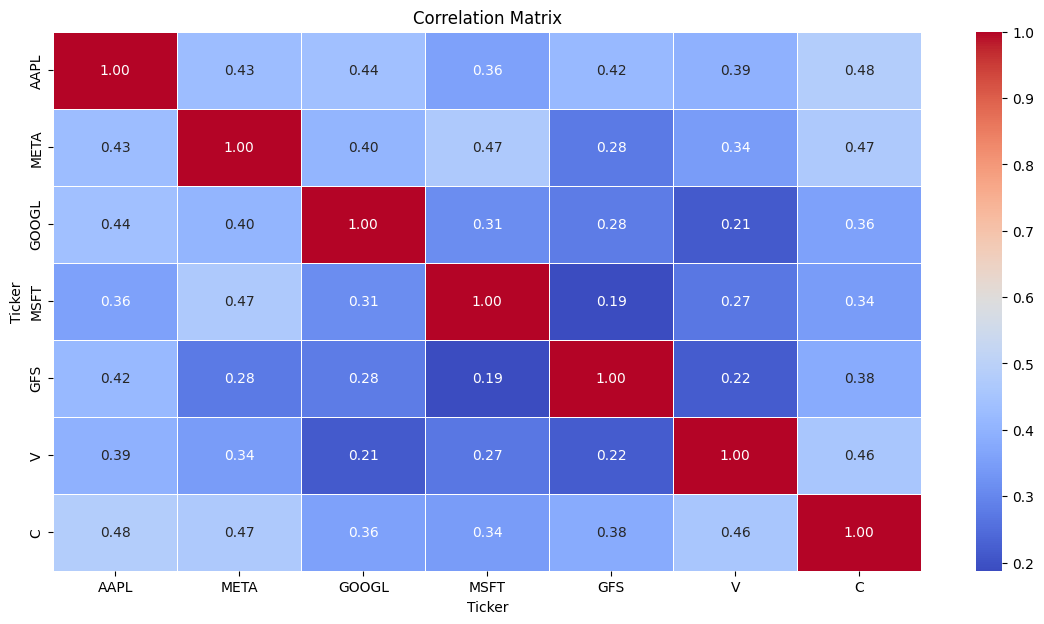

Highest correlation: ('AAPL', 'C') (0.48)
Lowest correlation: ('GFS', 'MSFT') (0.19)
Portfolio includes low-correlation assets that may improve diversification.
GFS provides the strongest diversification benefit.

===== CAPM Summary =====


,Ticker,Benchmark,Alpha,Alpha Annualized (%),Beta,R Squared,Residual Volatility,Residual Vol Annualized (%)
0,AAPL,SPY,-0.000306,-7.717088,1.172636,0.482628,0.013710,21.764678
1,AAPL,VOO,-0.000333,-8.382458,1.210932,0.474927,0.013812,21.926064
2,AAPL,QQQ,-0.000342,-8.615643,0.854497,0.414142,0.014590,23.160442
3,META,SPY,-0.000962,-24.230791,1.418666,0.430262,0.018435,29.264746
4,META,VOO,-0.000999,-25.169963,1.472309,0.427634,0.018478,29.332176
5,META,QQQ,-0.001089,-27.454518,1.115074,0.429559,0.018446,29.282808
6,GOOGL,SPY,0.001026,25.854557,1.077574,0.365014,0.016050,25.478171
7,GOOGL,VOO,0.000993,25.034440,1.124136,0.366568,0.016030,25.446985
8,GOOGL,QQQ,0.000913,23.007666,0.862128,0.377573,0.015890,25.224957
9,MSFT,SPY,-0.000910,-22.937159,0.876601,0.324549,0.014281,22.670049


,Ticker,VaR (%),CVaR (%)
0,AAPL,-3.173290,-4.374658
1,META,-3.325729,-5.514011
2,GOOGL,-2.634222,-4.076847
3,MSFT,-2.691275,-3.918129
4,GFS,-4.858736,-6.597600
5,V,-2.225838,-3.377586
6,C,-3.052009,-4.691846


Saved: output/data/Ticker_Daily_Return.csv✅
Saved: output/data/Ticker_Performance_Summary.csv✅
Saved: output/data/Ticker_CAPM_Summary.csv✅
Saved: output/data/Ticker_CVAR_VAR.csv✅
Saved: output/data/Benchmark_Daily_Return.csv✅


In [5]:
# ==========================================================
# Ticker Performance Summary
# ==========================================================
ticker_summary_df = calculate_performance_summary(
    daily_return=ticker_daily_return,
    risk_free_rate_annual=risk_free_rate_annual,
    trading_days=trading_days
)
print("\n\n===== Individual Asset Performance Summary =====")
print(ticker_summary_df)

# ==========================================================
# Ticker Key Insights
# ==========================================================
generate_ticker_summary(
    ticker_summary_df=ticker_summary_df
)

# ==========================================================
# Covariance and Correlation Matrix for each ticker 
# ==========================================================
cov_matrix, corr_matrix = calculate_cov_corr_matrix(
    return_df=ticker_daily_return
)

plot_correlation_heatmap(
    corr_matrix=corr_matrix,
    filename="Ticker_Correlation_Matrix.png",
    output_dir=plot_dir
)

generate_correlation_summary(
    corr_matrix=corr_matrix)

# =========================================================
# Alpha / Beta / R^2 / Residual Risk (Epsilon) using CAPM
# =========================================================
ticker_capm_results = []
ticker_capm_summary_df = generate_capm_summary(
    capm_results=ticker_capm_results,
    daily_return_df=ticker_daily_return,
    benchmark_daily_return=benchmark_daily_return,
    trading_days=trading_days,
    asset_label="Ticker"
)

print("\n===== CAPM Summary =====")
display(ticker_capm_summary_df)

# =========================================================
# VaR and CVaR per ticker
# =========================================================

cvar_var_ticker_df= calculate_var_cvar(
    return_data=ticker_daily_return,
    confidence_level=0.95,
    asset_label="Ticker"
)
display(cvar_var_ticker_df)

# Save the output df
save_dataframe(df=ticker_daily_return, filename="Ticker_Daily_Return.csv", output_dir=data_dir)
save_dataframe(df=ticker_summary_df, filename="Ticker_Performance_Summary.csv", output_dir=data_dir)
save_dataframe(df=ticker_capm_summary_df, filename="Ticker_CAPM_Summary.csv", output_dir=data_dir)
save_dataframe(df=cvar_var_ticker_df, filename="Ticker_CVAR_VAR.csv",output_dir=data_dir)
save_dataframe(df=benchmark_daily_return, filename="Benchmark_Daily_Return.csv", output_dir=data_dir)

In [6]:
# ==========================================================
# Ticker Rolling Sharpe / Volatility 
# ==========================================================
ticker_rolling_metrics = calculate_rolling_metric_summary(
    return_df=ticker_daily_return,
    rolling_period=rolling_period,
    risk_free_rate_annual=risk_free_rate_annual,
    trading_days=trading_days
)

ticker_rolling_return = ticker_rolling_metrics["Rolling Return"]
ticker_rolling_volatility = ticker_rolling_metrics["Rolling Volatility"]
ticker_rolling_sharpe = ticker_rolling_metrics["Rolling Sharpe"]

# ==========================================================
# Benchmark Rolling Sharpe / Volatility  
# ==========================================================
benchmark_return_df = pd.DataFrame({
    benchmark_ticker: benchmark_daily_return[benchmark_ticker]
    for benchmark_ticker in benchmark_daily_return.columns
    })   

benchmark_rolling_metrics = calculate_rolling_metric_summary(
    return_df=benchmark_daily_return,
    rolling_period=rolling_period,
    risk_free_rate_annual=risk_free_rate_annual,
    trading_days=trading_days
)
benchmark_rolling_volatility = benchmark_rolling_metrics["Rolling Volatility"]
benchmark_rolling_sharpe = benchmark_rolling_metrics["Rolling Sharpe"]

# ==========================================================
# Ticker Rolling Beta 
# ==========================================================
ticker_rolling_beta_df = generate_rolling_beta_summary(
    return_df=ticker_daily_return,
    benchmark_daily_return=benchmark_daily_return,
    rolling_period=rolling_period,
    asset_label="Ticker"
)

Saved: output/data/Ticker_30-Day_Rolling_Volatility.csv✅
Saved: output/plots/ticker_rolling_volatility.png✅


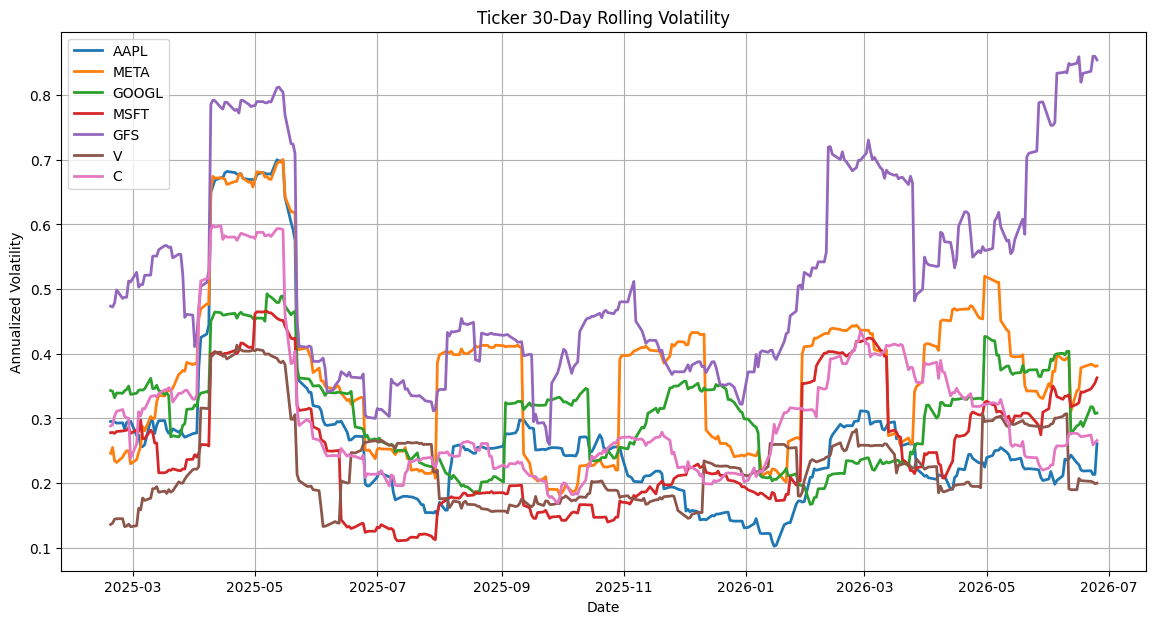

Saved: output/data/Ticker_30-Day_Rolling_Sharpe.csv✅
Saved: output/plots/Ticker_rolling_sharpe.png✅


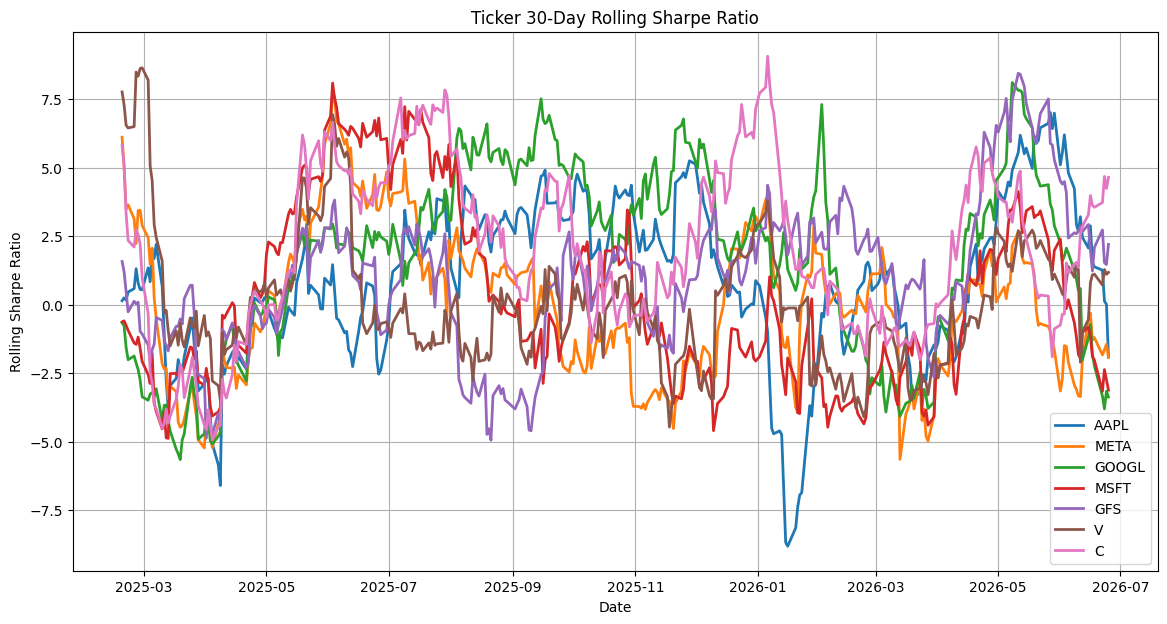

Saved: output/data/Ticker_30-Day_Rolling_Beta.csv✅
Saved: output/plots/ticker_rolling_beta.png✅


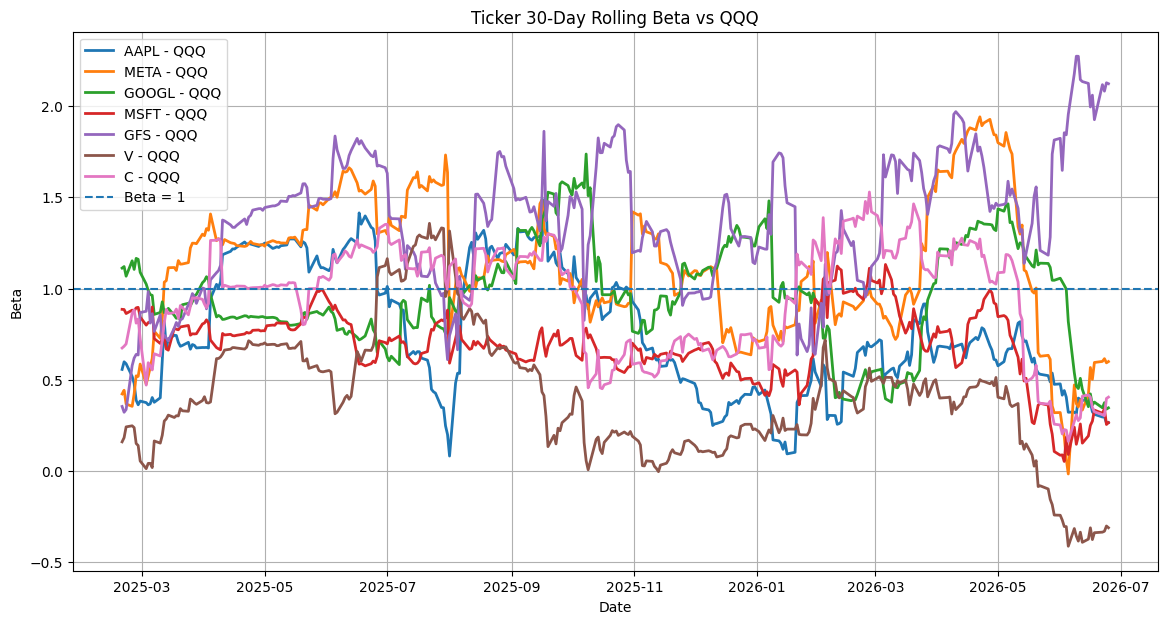

In [7]:
# ==========================================================
# Plotting Ticker Rolling Volatility / Sharpe / Beta Trend 
# ==========================================================
# Rolling Volatility
save_dataframe(df=ticker_rolling_volatility, filename=f"Ticker_{rolling_period}-Day_Rolling_Volatility.csv", output_dir=data_dir)
plot_rolling_metric(
    rolling_metric_df=ticker_rolling_volatility,
    plot_benchmark=None,
    benchmark_rolling_metric_df=None,
    rolling_period=user_config["rolling_period"],
    title=f"Ticker {rolling_period}-Day Rolling Volatility",
    ylabel="Annualized Volatility",
    filename="ticker_rolling_volatility.png",
    plot_dir=plot_dir
)

# Rolling Sharpe
save_dataframe(df=ticker_rolling_sharpe, filename=f"Ticker_{rolling_period}-Day_Rolling_Sharpe.csv", output_dir=data_dir)
plot_rolling_metric(
    rolling_metric_df=ticker_rolling_sharpe,
    plot_benchmark=None,
    benchmark_rolling_metric_df=None,
    rolling_period=user_config["rolling_period"],
    title=f"Ticker {rolling_period}-Day Rolling Sharpe Ratio",
    ylabel="Rolling Sharpe Ratio",
    filename=f"Ticker_rolling_sharpe.png",
    plot_dir=plot_dir,
)

# Rolling Beta
save_dataframe(df=ticker_rolling_beta_df, filename=f"Ticker_{rolling_period}-Day_Rolling_Beta.csv", output_dir=data_dir)
plot_rolling_beta(
    rolling_beta_df=ticker_rolling_beta_df,
    asset_label="Ticker",
    rolling_period=rolling_period,
    benchmark_filter=user_config["benchmark_filter"],
    filename="ticker_rolling_beta.png",
    plot_dir=plot_dir
)

### 6. Portfolio Optimization

In [8]:
# ==========================================================
# Portfolio Recommendation Engine
# ==========================================================
generate_portfolio_explanation()

Portfolio Insights:
- Equal Weight Portfolio provides balanced diversification across assets. (Balanced Investor)
- Max Sharpe Portfolio provides the best risk-adjusted return. (Aggresive Investor)
- Min Volatility Portfolio provides the lowest portfolio risk. (Conservative Investor)


In [9]:
# ==========================================================
# Equal Weight Portfolio
# ==========================================================
equal_weight_portfolio_df, equal_weights = generate_equal_weight_portfolio_summary(
    ticker_daily_return=ticker_daily_return,
    ticker_summary_df=ticker_summary_df,
    cov_matrix=cov_matrix,
    trading_days=trading_days,
    risk_free_rate_annual=risk_free_rate_annual
)

Equal Weight Portfolio Model Generated...
Number of tickers: 7
Weight per ticker: 14%

Portfolio Return: 26.32%
Portfolio Volatility: 22.89%
Portfolio Sharpe Ratio: 1.02
Portfolio demonstrates strong risk-adjusted performance.


Generating 10000 Monte Carlo Simulations...

===== Max Sharpe Portfolio Weightage =====


,Ticker,Weight,Weight_Display
0,AAPL,0.030018,3.00%
1,META,0.025774,2.58%
2,GOOGL,0.397438,39.74%
3,MSFT,0.013946,1.39%
4,GFS,0.066875,6.69%
5,V,0.083964,8.40%
6,C,0.381985,38.20%


Saved: output/data/Max_Sharpe_Portfolio_Allocation.csv✅
Saved: output/plots/Max_Sharpe_Portfolio_Allocation.png✅


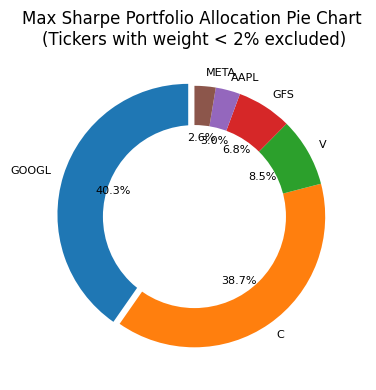


===== Min Volatility Portfolio Weightage =====


,Ticker,Weight,Weight_Display
0,AAPL,0.097480,9.75%
1,META,0.010645,1.06%
2,GOOGL,0.155814,15.58%
3,MSFT,0.352709,35.27%
4,GFS,0.018295,1.83%
5,V,0.351075,35.11%
6,C,0.013983,1.40%


Saved: output/data/Min_Volatility_Portfolio_Allocation.csv✅
Saved: output/plots/Min_Volatility_Portfolio_Allocation.png✅


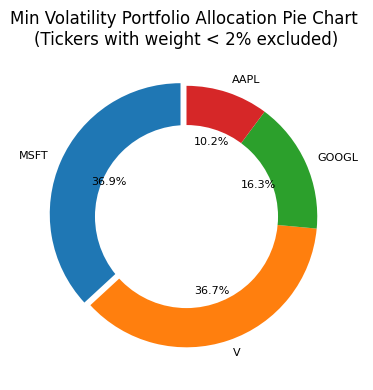

In [10]:
# ==========================================================
# Monte Carlo Portfolio Simulation
# ==========================================================
portfolio_simulation_df = generate_monte_carlo_portfolio(
        num_portfolios=user_config["num_portfolios"],
        daily_ticker_return=ticker_daily_return,
        trading_days=trading_days,
        risk_free_rate_annual=risk_free_rate_annual
)
print(f"Generating {user_config["num_portfolios"]} Monte Carlo Simulations...")

# ==========================================================
# Optimal Portfolio Weights
# ==========================================================
max_sharpe_portfolio, min_vol_portfolio = generate_optimal_portfolio(portfolio_simulation_df=portfolio_simulation_df)

# 1. Max Sharpe Ratio Portfolio
max_sharpe_weight_df = generate_optimal_portfolio_weight_display(
        portfolio_simulation_df=max_sharpe_portfolio,
        ticker_daily_return=ticker_daily_return,
        portfolio_type="Max Sharpe"
)
display(max_sharpe_weight_df)

save_dataframe(df=max_sharpe_weight_df,filename="Max_Sharpe_Portfolio_Allocation.csv",output_dir=data_dir)
plot_weightage_chart(
    weights_df=max_sharpe_weight_df,
    portfolio_type="Max Sharpe",
    filename="Max_Sharpe_Portfolio_Allocation.png",
    plot_dir=plot_dir,
) 

# 2. Min Vol Portfolio
min_vol_weight_df = generate_optimal_portfolio_weight_display(
        portfolio_simulation_df=min_vol_portfolio,
        ticker_daily_return=ticker_daily_return,
        portfolio_type="Min Volatility"
)
display(min_vol_weight_df)

save_dataframe(df=min_vol_weight_df,filename="Min_Volatility_Portfolio_Allocation.csv",output_dir=data_dir)
plot_weightage_chart(
    weights_df=min_vol_weight_df,
    portfolio_type="Min Volatility",
    filename="Min_Volatility_Portfolio_Allocation.png",
    plot_dir=plot_dir,
)   

Saved: output/data/Portfolio_Simulation_Data.csv✅
Saved: output/plots/Portfolio_Efficient_Frontier_10000-Simulations.png✅


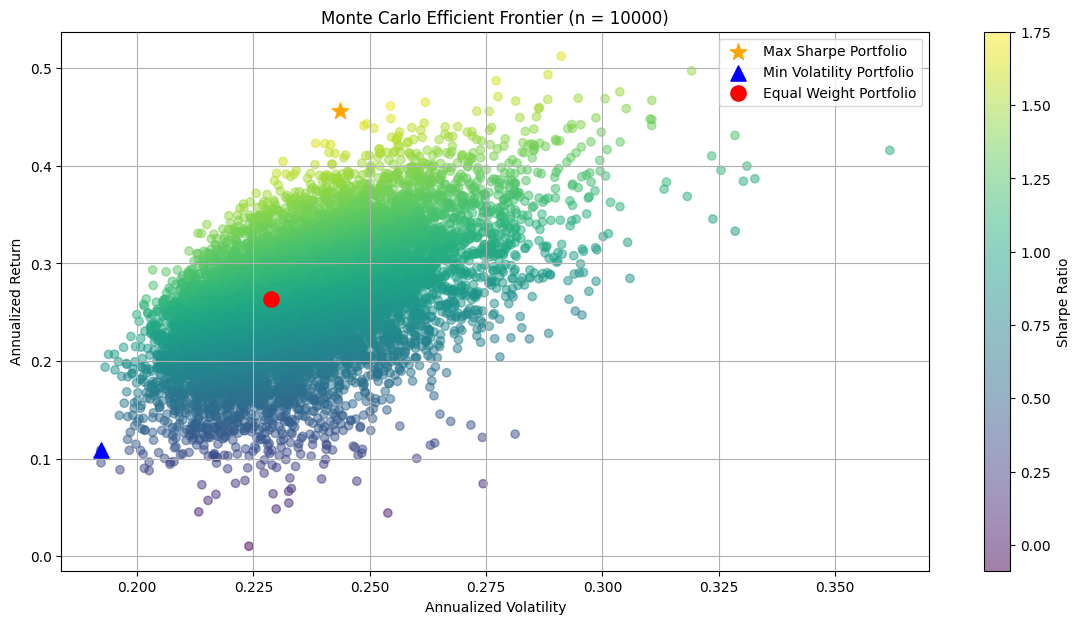

In [11]:
# ==========================================================
# Monte Carlo Risk-Return Plot
# ==========================================================
save_dataframe(df=portfolio_simulation_df, filename="Portfolio_Simulation_Data.csv", output_dir=data_dir)
plot_monte_carlo_efficient_frontier(
    portfolio_simulation_df=portfolio_simulation_df,
    max_sharpe_portfolio=max_sharpe_portfolio,
    min_vol_portfolio=min_vol_portfolio,
    equal_weight_metrics=equal_weight_portfolio_df,
    num_portfolios=user_config["num_portfolios"],
    filename=f"Portfolio_Efficient_Frontier_{user_config["num_portfolios"]}-Simulations.png",
    plot_dir=plot_dir
)

### 7. Risk Analysis

In [12]:
# ==========================================================
# Portfolio Daily Return 
# ==========================================================
# 1. Max Sharpe Portfolio
max_sharpe_portfolio_daily_return = calculate_portfolio_daily_return(
    ticker_daily_return=ticker_daily_return,
    weights=max_sharpe_weight_df
)
# 2. Min Vol Portfolio
min_vol_portfolio_daily_return = calculate_portfolio_daily_return(
    ticker_daily_return=ticker_daily_return,
    weights=min_vol_weight_df
)

# 3. Equal Weight Portfolio
equal_weight_portfolio_daily_return = calculate_portfolio_daily_return(
    ticker_daily_return=ticker_daily_return,
    weights=equal_weights
)

# 4. Combined
portfolio_return_df = generate_portfolio_dataframe(
    max_sharpe_portfolio=max_sharpe_portfolio_daily_return,
    min_vol_portfolio=min_vol_portfolio_daily_return,
    equal_weight_portfolio=equal_weight_portfolio_daily_return,
    parameter="Return"
)

# Save Portfolio daily return data
print("\nSaving Portfolio/Benchmark Daily Return...")
save_dataframe(df=benchmark_return_df, filename="Benchmark_Daily_Return.csv", output_dir=data_dir)
save_dataframe(df=portfolio_return_df, filename="Combined_Portfolio_Daily_Return.csv", output_dir=data_dir)


# ==========================================================
# Portfolio/Benchmark $1 Growth
# ==========================================================
# 1. Max Sharpe Ratio Portfolio Growth
max_sharpe_growth = calculate_growth(portfolio_benchmark_daily_return=max_sharpe_portfolio_daily_return)

# 2. Min Vol Portfolio Growth
min_vol_growth = calculate_growth(portfolio_benchmark_daily_return=min_vol_portfolio_daily_return)

# 3. Equal Weight Portfolio Growth
equal_weight_growth = calculate_growth(portfolio_benchmark_daily_return=equal_weight_portfolio_daily_return)

# 4. Combined all portfolios growth
portfolio_growth_df = generate_portfolio_dataframe(
    max_sharpe_portfolio=max_sharpe_growth,
    min_vol_portfolio=min_vol_growth,
    equal_weight_portfolio=equal_weight_growth,
    parameter="Growth"
)

# 5. Benchmark growth
benchmark_growth_df = calculate_growth(portfolio_benchmark_daily_return=benchmark_daily_return)

# Save Portfolio Growth
print("\nSaving Portfolio/Benchmark Growth...")
save_dataframe(df=benchmark_growth_df, filename="Benchmark_Growth.csv", output_dir=data_dir)
save_dataframe(df=portfolio_growth_df, filename="Combined_Portfolio_Growth.csv", output_dir=data_dir)

# ==========================================================
# Portfolio/Benchmark Drawdown
# ==========================================================
# 1. Max Sharpe Ratio Portfolio
max_sharpe_drawdown, max_sharpe_maxdrawdown = calculate_drawdown(growth_df=max_sharpe_growth)

# 2. Min Vol Portfolio
min_vol_drawdown, min_vol_maxdrawdown = calculate_drawdown(growth_df=min_vol_growth)

# 3. Equal Weight Portfolio
equal_weight_drawdown, equal_portfolio_maxdrawdown = calculate_drawdown(growth_df=equal_weight_growth)

# 4. Combined all portfolios drawdown and Max Drawdown
portfolio_drawdown_df = generate_portfolio_dataframe(
    max_sharpe_portfolio=max_sharpe_drawdown,
    min_vol_portfolio=min_vol_drawdown,
    equal_weight_portfolio=equal_weight_drawdown,
    parameter="Drawdown"
)

portfolio_maxdrawdown = generate_portfolio_dataframe(
    max_sharpe_portfolio=max_sharpe_maxdrawdown,
    min_vol_portfolio=min_vol_maxdrawdown,
    equal_weight_portfolio=equal_portfolio_maxdrawdown,
    parameter="Max Drawdown"
)

# 5. Benchmark 
benchmark_drawdown_df, benchmark_maxdrawdown = calculate_drawdown(growth_df=benchmark_growth_df)

# Save Portfolio Drawdown
print("\nSaving Portfolio/Benchmark Drawdown...")
save_dataframe(df=benchmark_drawdown_df, filename="Benchmark_Drawdown.csv", output_dir=data_dir)
save_dataframe(df=portfolio_drawdown_df, filename="Combined_Portfolio_Drawdown.csv", output_dir=data_dir)

# ==========================================================
# Max Drawdown Summary
# ==========================================================
drawdown_summary_df = generate_drawdown_summary(
    portfolio_drawdown_df=portfolio_drawdown_df,
    benchmark_drawdown_df=benchmark_drawdown_df
)

# ==========================================================
# Combined (Portfolio/Benchmark) Summary Table
# ==========================================================
combined_summary_df= generate_combined_summary_table(
    portfolio_daily_return_df=portfolio_return_df,
    benchmark_daily_return=benchmark_daily_return,
    drawdown_summary_df=drawdown_summary_df,
    risk_free_rate_annual=risk_free_rate_annual,
    trading_days=trading_days
)
save_dataframe(df=combined_summary_df,filename="Portfolio_Benchmark_Summary_Table.csv",output_dir=data_dir)

portfolio_capm_summary_df = generate_capm_summary(
    capm_results=[],
    daily_return_df=portfolio_return_df,
    benchmark_daily_return=benchmark_daily_return,
    trading_days=trading_days,
    asset_label="Portfolio"
)

display(portfolio_capm_summary_df)

save_dataframe(df=portfolio_capm_summary_df,filename="Portfolio_CAPM_Summary.csv",output_dir=data_dir)


generate_optimal_portfolio_summary(
    portfolio_name="Max Sharpe Portfolio",
    portfolio_metrics=max_sharpe_portfolio,
    max_drawdown=max_sharpe_maxdrawdown,
    equal_weight_summary_df=equal_weight_portfolio_df,
    objective="max_sharpe"
)

generate_optimal_portfolio_summary(
    portfolio_name="Min Volatility Portfolio",
    portfolio_metrics=min_vol_portfolio,
    max_drawdown=min_vol_maxdrawdown,
    equal_weight_summary_df=equal_weight_portfolio_df,
    objective="min_vol"
)


Saving Portfolio/Benchmark Daily Return...
Saved: output/data/Benchmark_Daily_Return.csv✅
Saved: output/data/Combined_Portfolio_Daily_Return.csv✅

Saving Portfolio/Benchmark Growth...
Saved: output/data/Benchmark_Growth.csv✅
Saved: output/data/Combined_Portfolio_Growth.csv✅

Saving Portfolio/Benchmark Drawdown...
Saved: output/data/Benchmark_Drawdown.csv✅
Saved: output/data/Combined_Portfolio_Drawdown.csv✅


,Annual Return (%),Volatility (%),Sharpe Ratio,Type,Max Drawdown (%),Max Drawdown Display,Return Rank,Volatility Rank,Sharpe Rank,Max Drawdown Rank
Max Sharpe Portfolio,45.655459,24.370745,1.750273,Portfolio,-25.957713,-25.96%,1.0,6.0,1.0,1.0
Equal Weight Portfolio,26.318537,22.888129,1.018805,Portfolio,-24.459592,-24.46%,2.0,5.0,3.0,2.0
Min Volatility Portfolio,10.866723,19.221198,0.409273,Portfolio,-17.974241,-17.97%,6.0,3.0,6.0,6.0
Benchmark (QQQ),26.282552,22.788462,1.021682,Benchmark,-22.768308,-22.77%,3.0,4.0,2.0,3.0
Benchmark (VOO),18.353776,17.220444,0.891602,Benchmark,-18.689394,-18.69%,5.0,1.0,4.0,5.0
Benchmark (SPY),18.385763,17.926430,0.858273,Benchmark,-18.755226,-18.76%,4.0,2.0,5.0,4.0


Saved: output/data/Portfolio_Benchmark_Summary_Table.csv✅


,Portfolio,Benchmark,Alpha,Alpha Annualized (%),Beta,R Squared,Residual Volatility,Residual Vol Annualized (%)
0,Max Sharpe Portfolio,SPY,0.000959,24.176791,1.168223,0.738416,0.007852,12.464475
1,Max Sharpe Portfolio,VOO,0.000923,23.266246,1.219870,0.742981,0.007783,12.355240
2,Max Sharpe Portfolio,QQQ,0.000894,22.536891,0.879617,0.676518,0.008732,13.860982
3,Min Volatility Portfolio,SPY,-0.000218,-5.485653,0.889404,0.688058,0.006763,10.735377
4,Min Volatility Portfolio,VOO,-0.000242,-6.105567,0.924730,0.686369,0.006781,10.764398
5,Min Volatility Portfolio,QQQ,-0.000255,-6.417569,0.657634,0.607907,0.007582,12.035798
6,Equal Weight Portfolio,SPY,0.000189,4.765155,1.172287,0.843014,0.005713,9.068623
7,Equal Weight Portfolio,VOO,0.000157,3.952051,1.218631,0.840645,0.005756,9.136772
8,Equal Weight Portfolio,QQQ,0.000111,2.803328,0.894708,0.793546,0.006551,10.399728


Saved: output/data/Portfolio_CAPM_Summary.csv✅

===== Max Sharpe Portfolio =====
Portfolio Return: 45.66%
Portfolio Volatility: 24.37%
Portfolio Sharpe Ratio: 1.75
Maximum Drawdown: -25.96%
Portfolio optimization improved risk-adjusted performance.

===== Min Volatility Portfolio =====
Portfolio Return: 10.87%
Portfolio Volatility: 19.22%
Portfolio Sharpe Ratio: 0.41
Maximum Drawdown: -17.97%
Portfolio optimization successfully reduced risk.


Saved: output/plots/Portfolio_Benchmark_Growth_Comparison.png✅


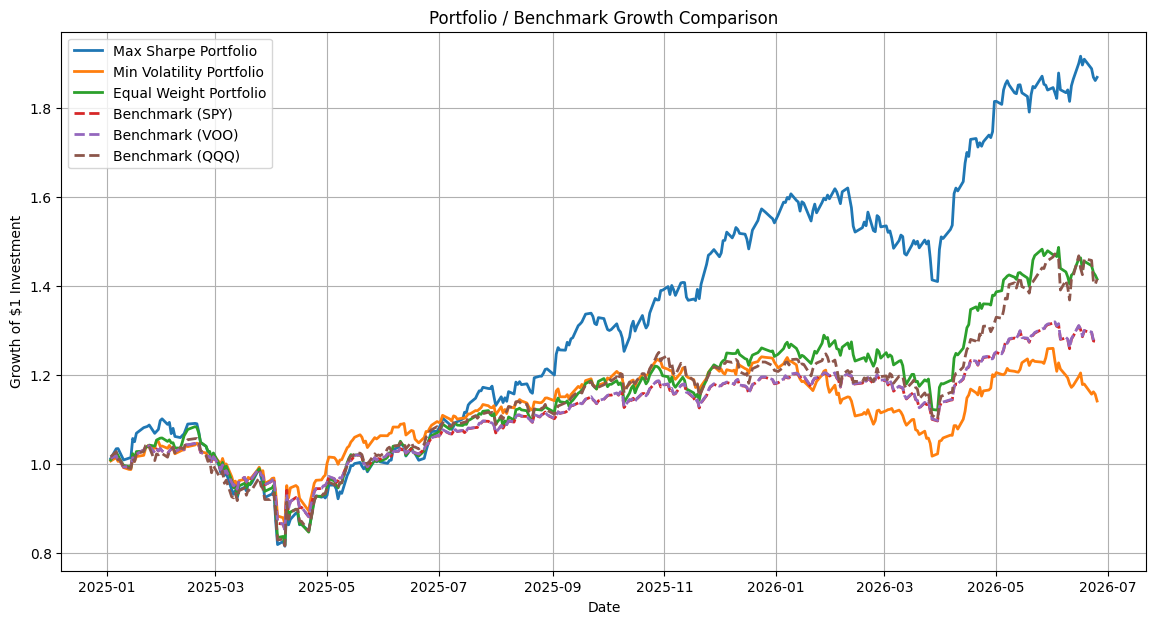

Saved: output/plots/Portfolio_Benchmark_Drawdown_Comparison.png✅


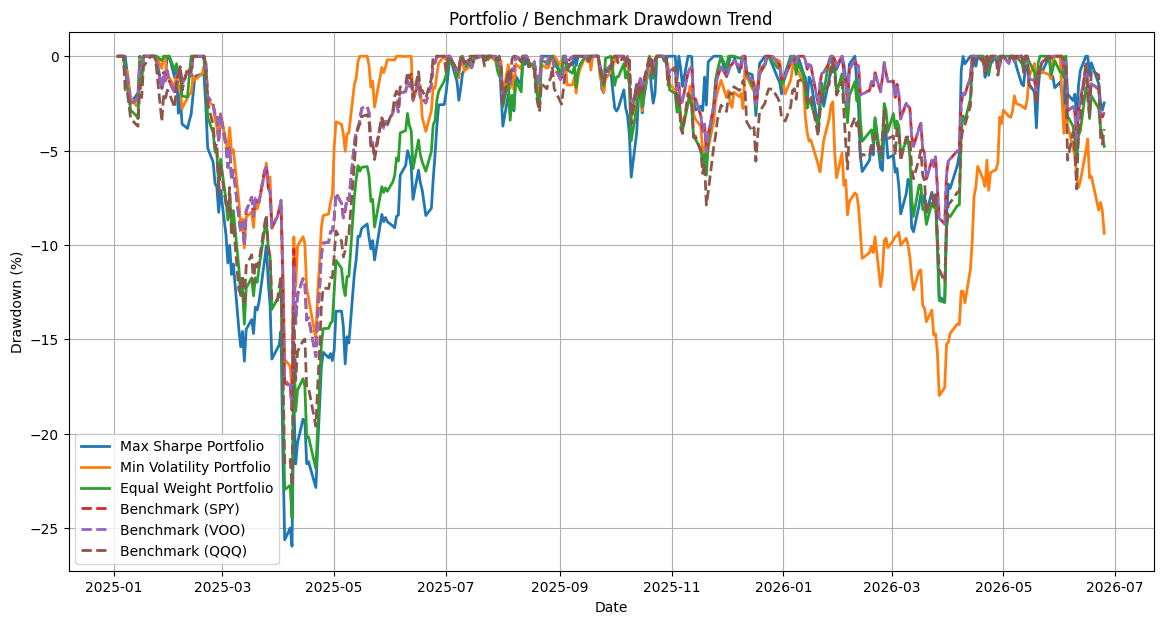

In [13]:
# ==========================================================
# Portfolio Growth Plotting
# ==========================================================
plot_portfolio_metric(
    portfolio_metric_df=portfolio_growth_df,
    benchmark_metric_df=benchmark_growth_df,
    title="Portfolio / Benchmark Growth Comparison",
    ylabel="Growth of $1 Investment",
    filename="Portfolio_Benchmark_Growth_Comparison.png",
    plot_dir=plot_dir
)

# ==========================================================
# Portfolio Drawdown Plotting
# ==========================================================
plot_portfolio_metric(
    portfolio_metric_df=portfolio_drawdown_df,
    benchmark_metric_df=benchmark_drawdown_df,
    title="Portfolio / Benchmark Drawdown Trend",
    ylabel="Drawdown (%)",
    filename="Portfolio_Benchmark_Drawdown_Comparison.png",
    plot_dir=plot_dir
)

In [14]:
# ==========================================================
# Portfolio and Benchmark VaR/CVaR Summary
# ==========================================================
portfolio_var_cvar_df=calculate_var_cvar(
    return_data = portfolio_return_df,
    confidence_level=0.95,
    asset_label="Portfolio"
)

benchmark_var_cvar_df=calculate_var_cvar(
    return_data=benchmark_return_df,
    confidence_level=0.95,
    asset_label="Benchmark"
)

print("===== Portfolio and Benchmark VaR/CVaR Summary =====")
display(portfolio_var_cvar_df)
display(benchmark_var_cvar_df)

===== Portfolio and Benchmark VaR/CVaR Summary =====


,Portfolio,VaR (%),CVaR (%)
0,Max Sharpe Portfolio,-2.047394,-3.153463
1,Min Volatility Portfolio,-1.813539,-2.609808
2,Equal Weight Portfolio,-2.106212,-3.093933


,Benchmark,VaR (%),CVaR (%)
0,SPY,-1.588350,-2.477498
1,VOO,-1.592114,-2.409687
2,QQQ,-2.038519,-3.210729


### 8. Rolling Analytics

Saved: output/data/Ticker_30-Day_Rolling_Volatility.csv✅
Saved: output/plots/Portfolio_Benchmark_Rolling_Volatility.png✅


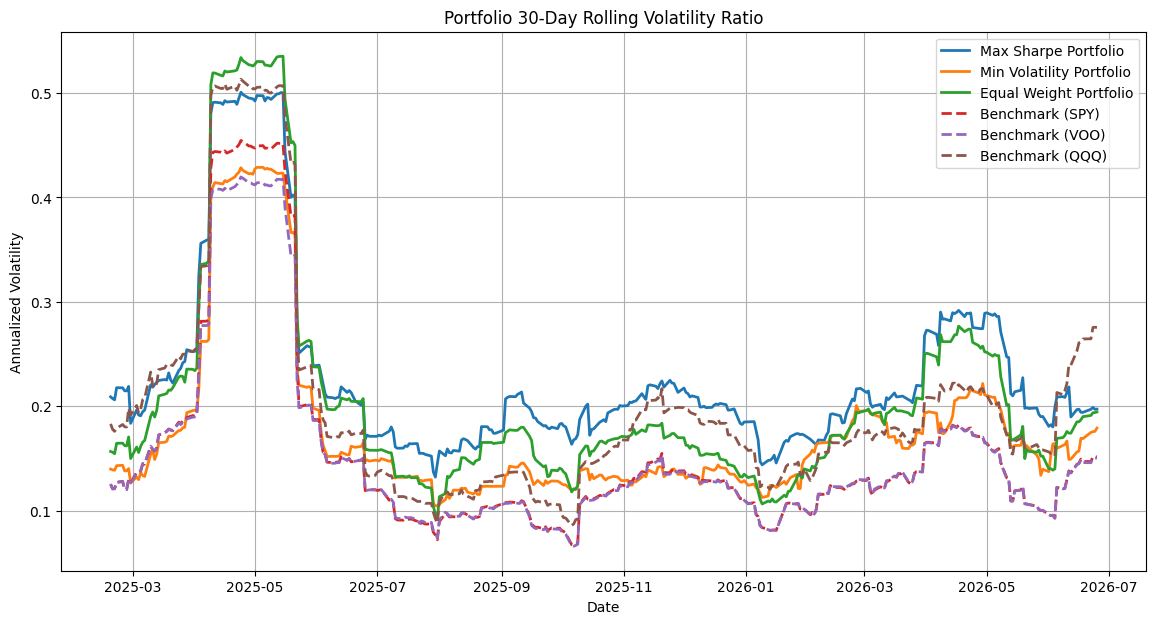

Saved: output/data/Ticker_30-Day_Rolling_Sharpe.csv✅
Saved: output/plots/Portfolio_Benchmark_Rolling_Sharpe.png✅


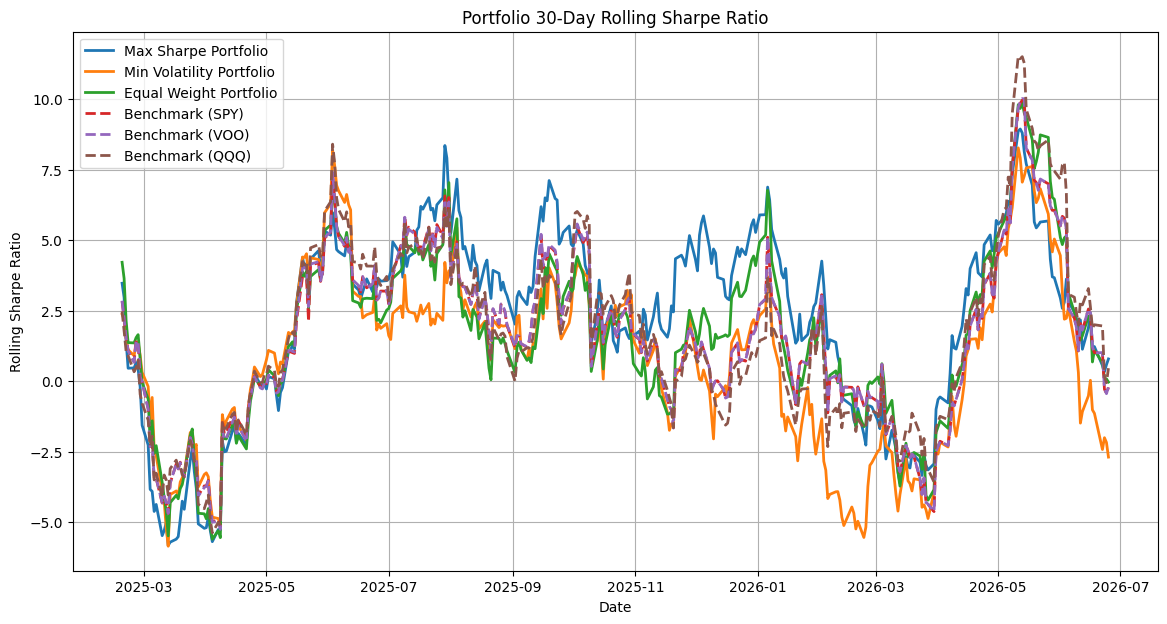

Saved: output/data/Portfolio_30-Day_Rolling_Beta.csv✅
Saved: output/plots/Portfolio_Rolling_Beta.png✅


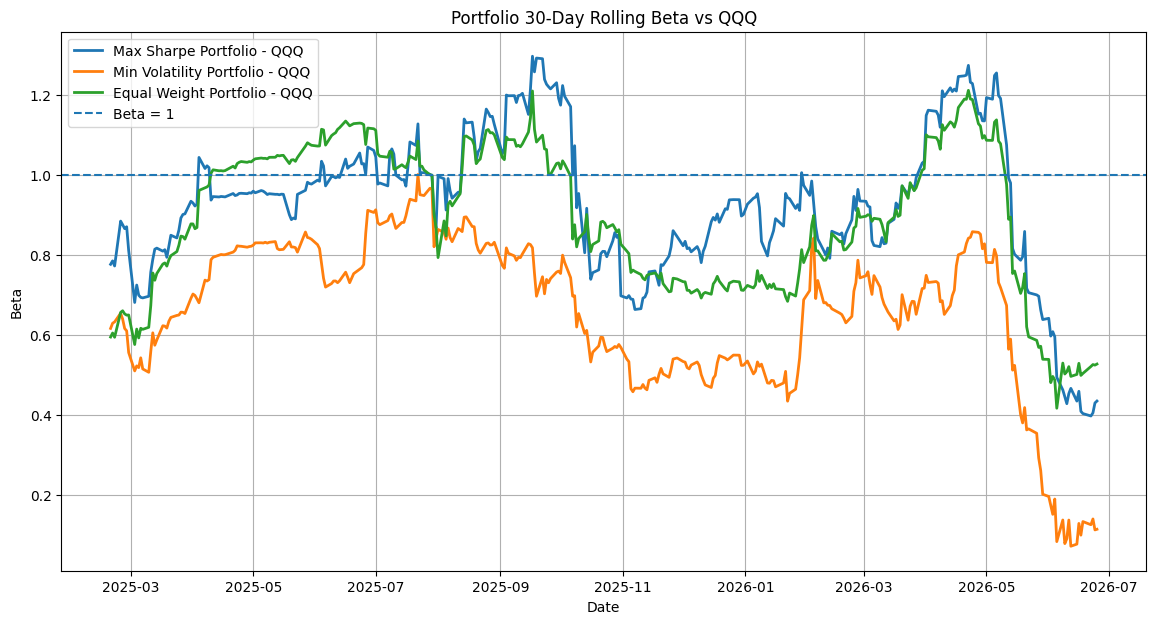

In [15]:
# ==========================================================
# Portfolio/Benchmark Rolling Volatility / Sharpe
# ==========================================================
portfolio_rolling_metrics = calculate_rolling_metric_summary(
    return_df=portfolio_return_df,
    rolling_period=rolling_period,
    risk_free_rate_annual=risk_free_rate_annual,
    trading_days=trading_days
)
portfolio_rolling_volatility = portfolio_rolling_metrics["Rolling Volatility"]
portfolio_rolling_sharpe = portfolio_rolling_metrics["Rolling Sharpe"]

# ==========================================================
# Portfolio/Benchmark Rolling Beta
# ==========================================================
portfolio_rolling_beta_df = generate_rolling_beta_summary(
    return_df=portfolio_return_df,
    benchmark_daily_return=benchmark_daily_return,
    rolling_period=rolling_period,
    asset_label="Portfolio"
)
# ==========================================================
# Portfolio/Benchmark Rolling Volatility Plot
# ==========================================================
save_dataframe(df=ticker_rolling_volatility, filename=f"Ticker_{rolling_period}-Day_Rolling_Volatility.csv", output_dir=data_dir)
plot_rolling_metric(
    rolling_metric_df=portfolio_rolling_volatility,
    plot_benchmark=user_config["plot_benchmark"],
    benchmark_rolling_metric_df=benchmark_rolling_volatility,
    rolling_period=user_config["rolling_period"],
    title=f"Portfolio {rolling_period}-Day Rolling Volatility Ratio",
    ylabel="Annualized Volatility",
    filename="Portfolio_Benchmark_Rolling_Volatility.png",
    plot_dir=plot_dir
)

# ==============================================
# Portfolio/Benchmark Rolling Sharpe Ratio Plot
# ==============================================
save_dataframe(df=ticker_rolling_sharpe, filename=f"Ticker_{rolling_period}-Day_Rolling_Sharpe.csv", output_dir=data_dir)
plot_rolling_metric(
    rolling_metric_df=portfolio_rolling_sharpe,
    plot_benchmark=user_config["plot_benchmark"],
    benchmark_rolling_metric_df=benchmark_rolling_sharpe,
    rolling_period=user_config["rolling_period"],
    title=f"Portfolio {rolling_period}-Day Rolling Sharpe Ratio",
    ylabel="Rolling Sharpe Ratio",
    filename="Portfolio_Benchmark_Rolling_Sharpe.png",
    plot_dir=plot_dir
)

# ==========================================================
# Portfolio/Benchmark Rolling Beta
# ==========================================================
save_dataframe(df=portfolio_rolling_beta_df, filename=f"Portfolio_{rolling_period}-Day_Rolling_Beta.csv", output_dir=data_dir)
plot_rolling_beta(
    rolling_beta_df=portfolio_rolling_beta_df,
    asset_label="Portfolio",
    rolling_period=rolling_period,
    benchmark_filter=user_config["benchmark_filter"],
    filename="Portfolio_Rolling_Beta.png",
    plot_dir=plot_dir
)